# 01 – Preprocesamiento y EDA

| Campo | Descripción |
|---|---|
| **Propósito** | Limpiar el dataset de reservas hoteleras, analizar la distribución de las variables, identificar y eliminar casos de data leakage, y exportar un dataset listo para feature engineering. |
| **Input** | `data_hotel_booking/hotel_bookings.csv` |
| **Fuente** | Hotel Booking Demand dataset — Nunes, Antonio, Almeida & Nunes (2019). *Data in Brief*, Vol. 22. |
| **Variable target** | `is_canceled` (0 = No cancelado / 1 = Cancelado). 
| **Output** | `data_hotel_booking/hotel_booking_clean.csv`.  Figuras en `Figures/EDA/` |

#### SETUP — Correr una sola vez para preparar el entorno

1. Abrir PowerShell y navegar al directorio del proyecto:
      cd "Proyecto Hoteles"

2. Crear el virtual environment:
      py -m venv Hotel.venv

3. Activarlo:
      Hotel.venv\Scripts\activate

4. Instalar dependencias:
      pip install pandas numpy matplotlib seaborn missingno squarify pycountry <y las que necesite>

5. Seleccionar el kernel en VS Code:
      Arriba a la derecha del notebook → Select Kernel → Hotel.venv


In [2]:
# Instalar de ser necesario
# pip install pandas numpy matplotlib seaborn missingno ipykernel squarify pycountry textwrap

# Carga de datos e import de librerias

In [3]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import squarify
import os
from pathlib import Path
import pandas as pd

In [4]:
# -------------------------------
# Crear carpetas del proyecto
# -------------------------------
root = Path.cwd()

# Carpeta para figuras de EDA
eda_path = root / "Figures" / "EDA"
eda_path.mkdir(parents=True, exist_ok=True)
print(f"Carpeta creada en: {eda_path}")

# Carpeta para datos
data_path = root / "data_hotel_booking"
data_path.mkdir(parents=True, exist_ok=True)
print(f"Carpeta creada en: {data_path}")

# -------------------------------
# Cargar dataset
# -------------------------------
file_path = data_path / "hotel_bookings.csv"
data = pd.read_csv(file_path, index_col=False)


Carpeta creada en: c:\Users\yair.barnatan\Desktop\Proyecto Hoteles\Figures\EDA
Carpeta creada en: c:\Users\yair.barnatan\Desktop\Proyecto Hoteles\data_hotel_booking


In [5]:
# -------------------------------
# Guardar shape antes de limpieza
# -------------------------------
shape_before = data.shape
print(f"Shape del dataset a la entrada: {shape_before}")
print(len(data.columns))

Shape del dataset a la entrada: (119390, 32)
32


In [ ]:
COLOR_NUMERICA = "#1f77b4" 
COLOR_CATEGORICA = "#ff7f0e"  
COLOR_EDA = "#37a5ffff"  
decisiones_limpieza_datos = ''


# Formato de valores y decisiones de agrupamiento

In [ ]:
# Convertir meses EN a ES
meses_en = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]
meses_es = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre" ]

map_meses = dict(zip(meses_en, meses_es))
data["arrival_date_month"] = data["arrival_date_month"].map(map_meses)

# -------------

# Diccionario de traducción de tipos de meal
map_meal = {
    "Undefined": "Sin paquete de comidas",
    "SC": "Sin paquete de comidas",
    "BB": "Desayuno incluido",
    "HB": "Media pensión",
    "FB": "Pensión completa"}

data["meal"] = data["meal"].map(map_meal)

# -------------
# Traduccion de market_segment
map_market_segment = {
    "Direct": "Directo",
    "Corporate": "Corporativo",
    "Online TA": "Agencia de viajes online",    
    "Offline TA/TO": "Agencia de viajes offline",   
    "Complementary": "Complementario",
    "Groups": "Grupos",
    "Undefined": "Sin segmentación",
    "Aviation": "Aviación"
}

data["market_segment"] = data["market_segment"].map(map_market_segment)

# -------------

# Mapear valores a texto de la VAR TARGET
data["is_canceled"] = data["is_canceled"].map({0: "No cancelado", 1: "Cancelado"})

# Valores faltantes

In [8]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

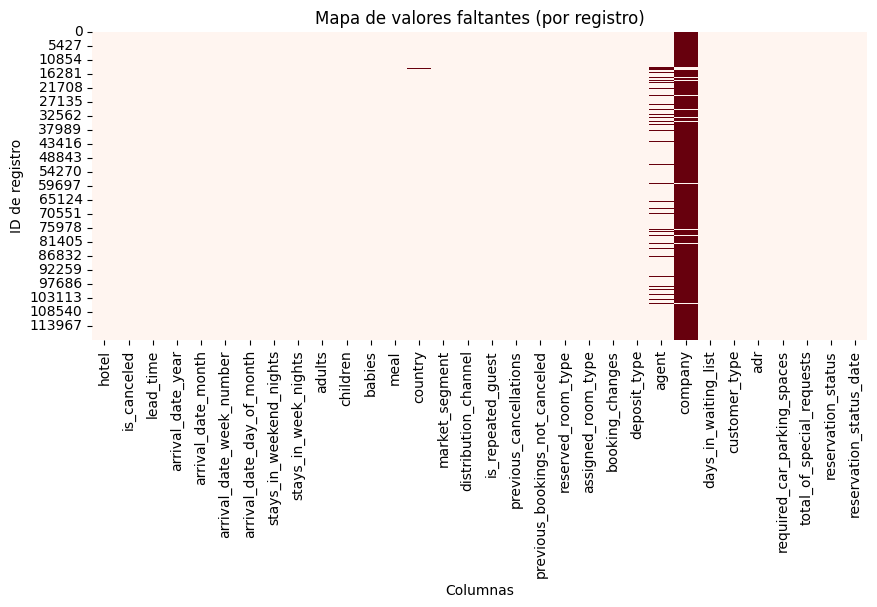

In [9]:
#Representar los datos faltantes con heatmap tipo raster
missing_map = data.isna().astype(int)

plt.figure(figsize=(10, 4))
sns.heatmap(missing_map, cmap="Reds", cbar=False)
plt.title("Mapa de valores faltantes (por registro)")
plt.xlabel("Columnas")
plt.ylabel("ID de registro")
plt.show()

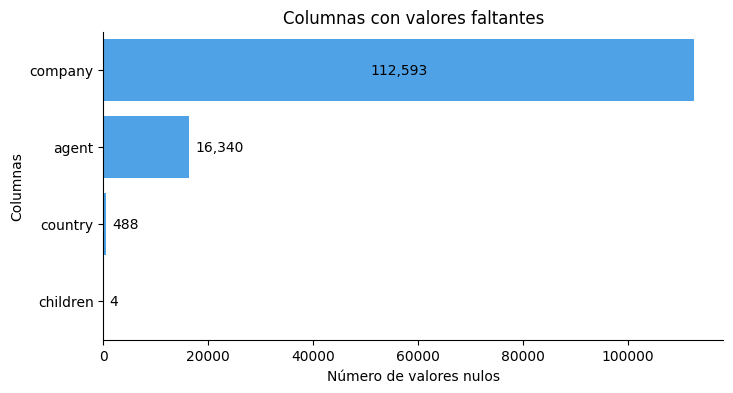

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
null_counts = data.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
plt.figure(figsize=(8,4))
ax = sns.barplot(x=null_counts.values, y=null_counts.index, color=COLOR_EDA)

sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
# -------------------------------------
x_max = ax.get_xlim()[1]

for i, v in enumerate(null_counts.values):
    if v > 0.5 * x_max:
        ax.text(v / 2, i, f"{v:,}", ha='center', va='center', color='black')
    else:
        ax.text(v + x_max * 0.01, i, f"{v:,}", ha='left', va='center', color='black')

plt.title("Columnas con valores faltantes")
plt.xlabel("Número de valores nulos")
plt.ylabel("Columnas")

plt.savefig("Figures/EDA/01_Conteo de nulos.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
nan_replacements = {"children": 0.0,"country": "Unknown", "agent": 0}
data_clean = data.fillna(nan_replacements)
decisiones_limpieza_datos += "Se reemplazaron los valores faltantes de las siguientes columnas: children, country, agent . Se asumió que si no hay valor en children, entonces no hay niños; si no hay valor en country, entonces el país es desconocido; y si no hay valor en agent  entonces la reserva fue hecha sin agencia o por un cliente privado respectivamente. \n " 

decisiones_limpieza_datos += f""" 
+   Se eliminó la columna company debido a la gran cantidad de valores faltantes. 
cuantos eran? eran {data_clean['company'].isnull().sum() / len(data_clean) }      \n """ 

data_clean = data_clean.drop(columns=["company"])

In [ ]:
zero_guests = list(data_clean.loc[data_clean["adults"]
                   + data_clean["children"]
                   + data_clean["babies"]==0].index)
data_clean.drop(data_clean.index[zero_guests], inplace=True)

decisiones_limpieza_datos += "+   Se eliminaron las reservas que no tenían ningún huésped (0 adultos, 0 niños y 0 bebés), ya que no son casos válidos para el análisis. \n "

# Valores duplicados

In [13]:
group_sizes = data_clean.groupby(list(data_clean.columns)).size()
group_sizes.value_counts().sort_index()

1      79058
2       5029
3        968
4        497
5        275
       ...  
100        1
101        1
109        1
150        1
180        1
Name: count, Length: 73, dtype: int64

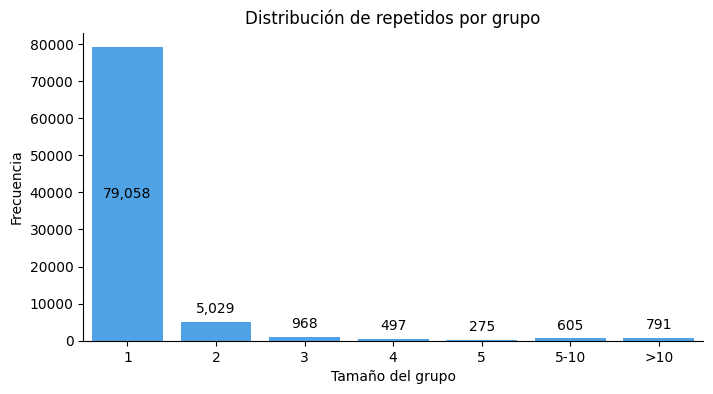

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("Figures/EDA", exist_ok=True)
group_sizes = data_clean.groupby(list(data_clean.columns)).size()
counts = group_sizes.value_counts()
bins = {
    "1": 0,
    "2": 0,
    "3": 0,
    "4": 0,
    "5": 0,
    "5-10": 0,
    ">10": 0
}

for k, v in counts.items():
    if k == 1:
        bins["1"] += v
    elif k == 2:
        bins["2"] += v
    elif k == 3:
        bins["3"] += v
    elif k == 4:
        bins["4"] += v
    elif k == 5:
        bins["5"] += v
    elif 6 <= k <= 10:
        bins["5-10"] += v
    elif k > 10:
        bins[">10"] += v

plot_data = list(bins.keys())
plot_values = list(bins.values())


plt.figure(figsize=(8,4))
ax = sns.barplot(x=plot_data, y=plot_values, color=COLOR_EDA)

sns.despine(ax=ax) 
# -------------------------------------

max_val = max(plot_values) if max(plot_values) > 0 else 1

for i, v in enumerate(plot_values):
    if v >= 0.5 * max_val:
        ax.text(i, v/2, f"{v:,}", ha='center', va='center', color='black')
    else:
        ax.text(i, v + max_val*0.02, f"{v:,}", ha='center', va='bottom', color='black')

plt.title("Distribución de repetidos por grupo")
plt.xlabel("Tamaño del grupo")
plt.ylabel("Frecuencia")
plt.savefig("Figures/EDA/01_Grupos de repetidos.png", dpi=300, bbox_inches="tight")
plt.show()

Elimino duplicados que se repitan mas de N_GROUP_SIZE   numero de veces
Ese N_GROUP_SIZE  es a piaccere.

In [ ]:
group_sizes = data_clean.groupby(list(data_clean.columns)).size()

N_GROUP_SIZE = 10
valid_groups = group_sizes[group_sizes <= N_GROUP_SIZE]

data_filtered = data_clean.merge(
    valid_groups.reset_index().drop(columns=0),
    on=list(data_clean.columns),
    how="inner"
)

decisiones_limpieza_datos += f"+   Se eliminaron las filas duplicadas que se repetían más de {N_GROUP_SIZE} veces, ya que podrían ser errores o casos atípicos.  Este valor fue estimado por el grafico, no sale de bilbiografia ni nada. Se mantuvieron las filas que se repetían hasta {N_GROUP_SIZE} veces, asumiendo que podrían ser casos válidos (i.e. hasta 10 reservas exactamente iguales). \n "

# Visualizando los plots


### Analisis univariado - Continuas   

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_histogram(df, col, color="orange", bins=30, kde=True, title=None, 
                   xlabel=None, ylabel=None, show_counts=True, save=False, filename=None):
    
    plt.figure(figsize=(8, 5))
    ax = sns.histplot(data=df, x=col, bins=bins, kde=kde, color=color)
    
    # --- ESTILO: Solo ejes X e Y ---
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    
    # 🔹 Mostrar conteos sobre las barras (Parametrizable)
    if show_counts:
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}', 
                            (p.get_x() + p.get_width()/2., height), 
                            ha='center', va='baseline', fontsize=9, 
                            xytext=(0, 3), textcoords='offset points')
    
    # Títulos y Ejes (Fontsize 14)
    plt.title(title if title else f"Distribución de {col}", fontsize=15, weight='bold', pad=15)
    plt.xlabel(xlabel if xlabel else col, fontsize=14)
    plt.ylabel(ylabel if ylabel else "Frecuencia", fontsize=14)
    
    plt.tight_layout()

    # 🔹 Lógica de guardado
    if save:
        os.makedirs("Figures/EDA", exist_ok=True)
        # Si no me das nombre, uso el de la columna
        name = filename if filename else f"hist_{col}.png"
        path = os.path.join("Figures/EDA", name)
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"✅ Gráfico guardado en: {path}")

    plt.show()

def plot_countplot(df, col, color="blue", title=None, xlabel=None, ylabel=None, 
                   order=None, xtick_rotation=25, show_counts=True, save=False, filename=None):
    
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df, x=col, order=order if order else df[col].value_counts().index, color=color)

    # --- ESTILO: Solo ejes X e Y ---
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # 🔹 Mostrar conteos sobre las barras (Parametrizable)
    if show_counts:
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}', 
                            (p.get_x() + p.get_width()/2., height), 
                            ha='center', va='baseline', fontsize=9, 
                            xytext=(0, 3), textcoords='offset points')

    # Títulos y Ejes (Fontsize 14)
    plt.title(title if title else f"Distribución de {col}", fontsize=15, weight='bold', pad=15)
    plt.xlabel(xlabel if xlabel else col, fontsize=14)
    plt.ylabel(ylabel if ylabel else "Frecuencia", fontsize=14)
    
    plt.xticks(rotation=xtick_rotation)
    plt.tight_layout()

    # 🔹 Lógica de guardado
    if save:
        os.makedirs("Figures/EDA", exist_ok=True)
        name = filename if filename else f"count_{col}.png"
        path = os.path.join("Figures/EDA", name)
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"✅ Gráfico guardado en: {path}")

    plt.show()

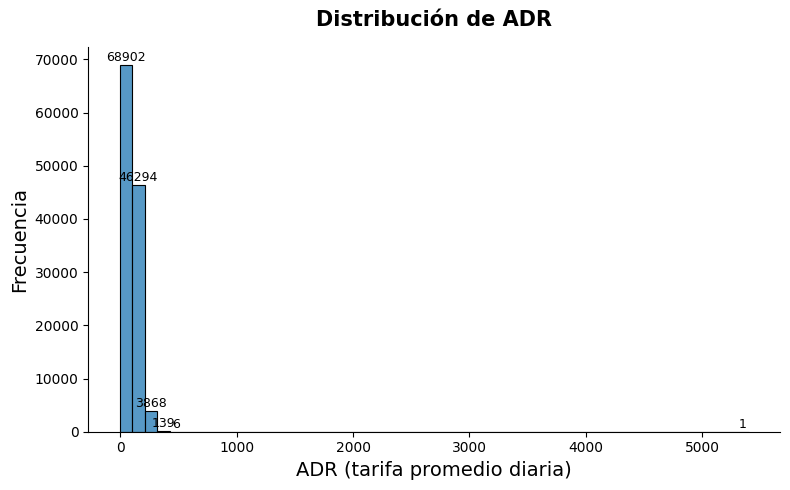

Valores de ADR mayores a 2000:
1


In [17]:
# ADR (Average Daily Rate) = Average daily rate as defined by dividing the sum of all lodging transactions by the total number of staying nights
plot_histogram(data_clean, 'adr', color=COLOR_NUMERICA, bins=50, kde=False, title="Distribución de ADR", xlabel="ADR (tarifa promedio diaria)", ylabel="Frecuencia")

#Decision: nada raro aunque hay un valor mega extremo, eliminarlo.
#Ver cuantos valores de ADR hay mayores a 2000
print("Valores de ADR mayores a 2000:")
print(data_clean[data_clean["adr"] > 2000].shape[0])
#Eliminar valores extremos de ADR 
data_clean = data_clean[data_clean["adr"] <= 2000]
decisiones_limpieza_datos +=  "+   Se eliminaron los valores de ADR mayores a 2000. \n "


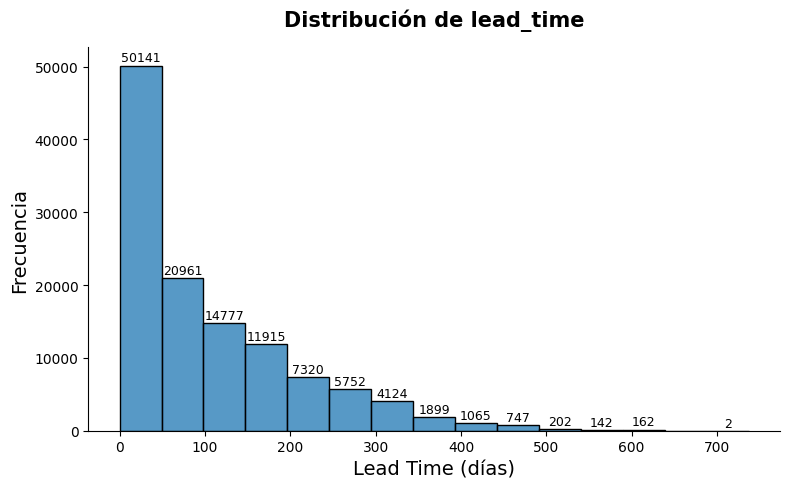

In [18]:
# lead_time = Number of days that elapsed between the entering date of the booking into the PMS and the arrival date. [i.e. tiempo de anticipacion de la reserva]
plot_histogram(data_clean, "lead_time", color=COLOR_NUMERICA, bins=15, kde=False, title="Distribución de lead_time", xlabel="Lead Time (días)", ylabel="Frecuencia")

#Decision: nada raro aca.

In [19]:
#Numero de leadtime == 0
print("Número de reservas con lead_time igual a 0:")
print(data_clean[data_clean["lead_time"] == 0].shape[0])

Número de reservas con lead_time igual a 0:
6264


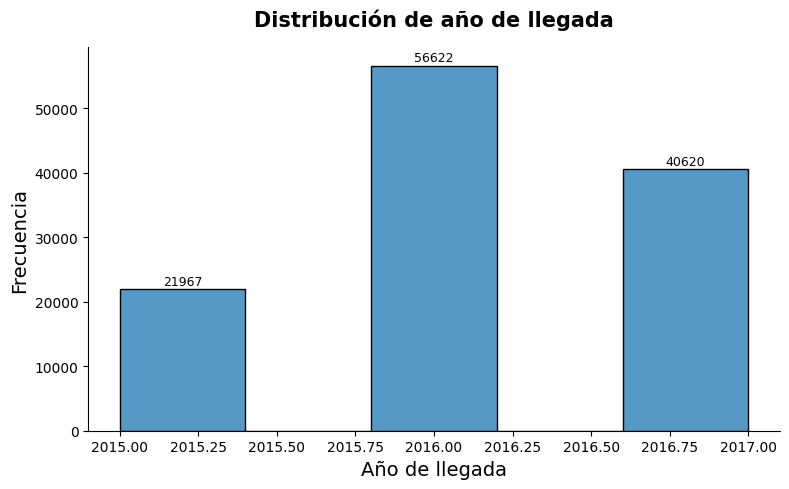

In [20]:
plot_histogram(data_clean, "arrival_date_year", color=COLOR_NUMERICA, bins=5, kde=False, title="Distribución de año de llegada", xlabel="Año de llegada", ylabel="Frecuencia")

# Decision: nada raro aca.

✅ Gráfico guardado en: Figures/EDA\03_Distribución de semana de llegada.png


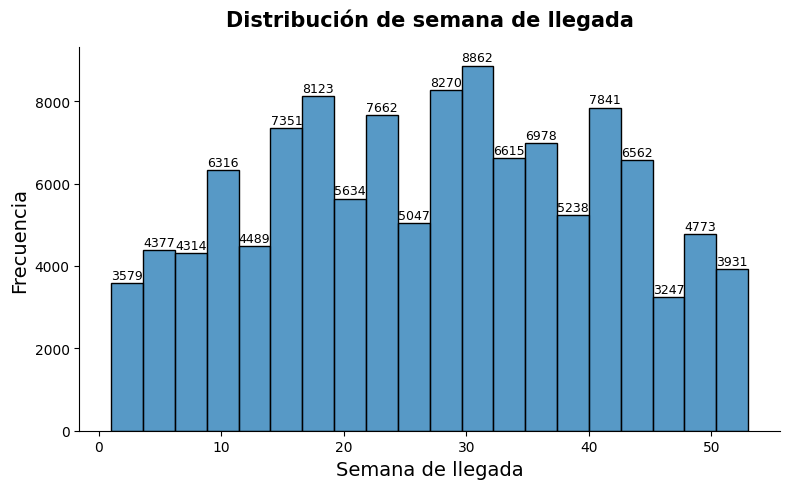

In [21]:
# plot_histogram(data_clean, 'arrival_date_week_number', color=COLOR_NUMERICA, bins=20, kde=False, title="Distribución de semana de llegada", xlabel="Semana de llegada", ylabel="Frecuencia")
plot_histogram(data_clean, 'arrival_date_week_number', color=COLOR_NUMERICA, bins=20,
               kde=False, title="Distribución de semana de llegada", xlabel="Semana de llegada", ylabel="Frecuencia",
               save=True, filename="03_Distribución de semana de llegada.png")

# Decision: nada raro aca.


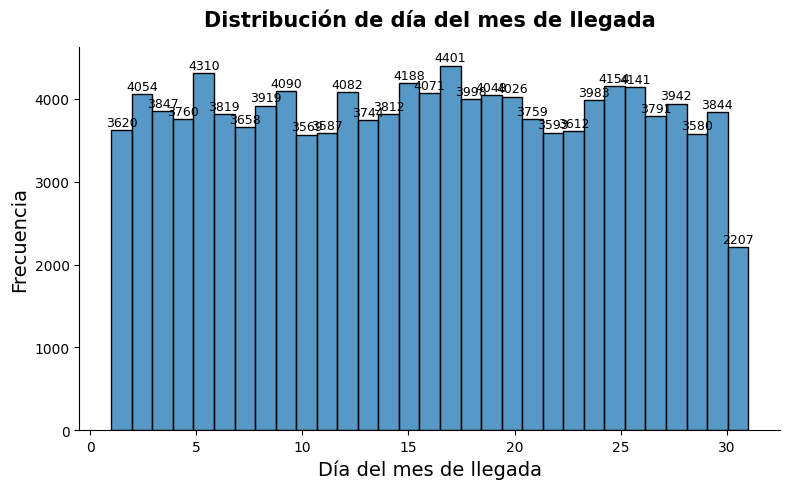

In [22]:
plot_histogram(data_clean, 'arrival_date_day_of_month', color=COLOR_NUMERICA, bins=31, kde=False, title="Distribución de día del mes de llegada", xlabel="Día del mes de llegada", ylabel="Frecuencia")

# Decision: nada raro aca.

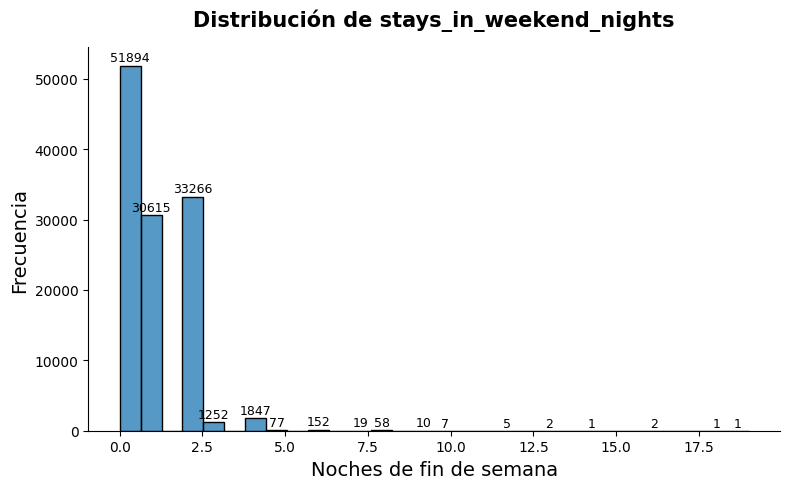

Número de reservas con más de 10 noches de fin de semana: 12


C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\3291056375.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("Número de reservas con más de 10 noches de fin de semana:", data_clean[data  ["stays_in_weekend_nights"] > 10].shape[0])


In [ ]:
plot_histogram(data_clean, "stays_in_weekend_nights", color=COLOR_NUMERICA, bins=30, kde=False, title="Distribución de stays_in_weekend_nights", xlabel="Noches de fin de semana", ylabel="Frecuencia")
print("Número de reservas con más de 10 noches de fin de semana:", data_clean[data  ["stays_in_weekend_nights"] > 10].shape[0])

data_clean = data_clean[data_clean["stays_in_weekend_nights"] <= 10]
decisiones_limpieza_datos += "+   Se eliminaron las reservas con más de 10 noches de fin de semana. \n  "

✅ Gráfico guardado en: Figures/EDA\04_Distribución de noches de semana.png


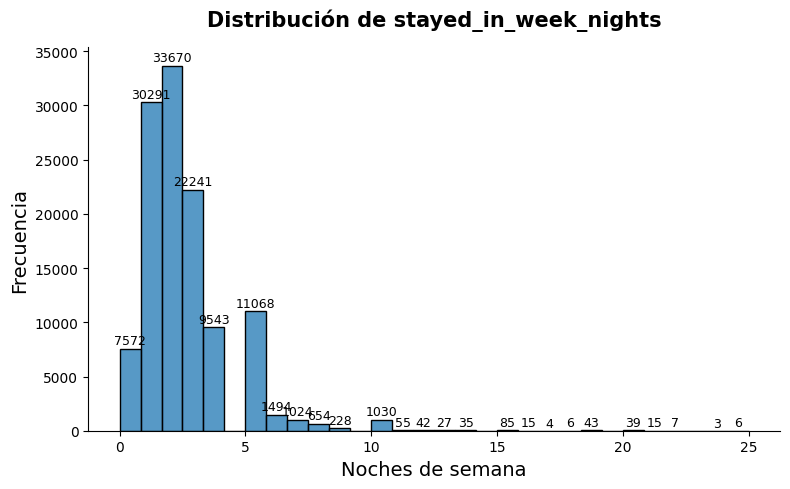

Número de reservas con más de 20 noches de semana: 31


In [ ]:

plot_histogram(data_clean, "stays_in_week_nights", color=COLOR_NUMERICA, bins=30, kde=False, 
               title="Distribución de stayed_in_week_nights", xlabel="Noches de semana", ylabel="Frecuencia",
               show_counts=True, save=True, filename="04_Distribución de noches de semana.png")

print("Número de reservas con más de 20 noches de semana:", data_clean[data_clean["stays_in_week_nights"] > 20].shape[0])

data_clean = data_clean[data_clean["stays_in_week_nights"] <= 20]
decisiones_limpieza_datos += "+   Se eliminaron las reservas con más de 20 noches de semana. \n     "


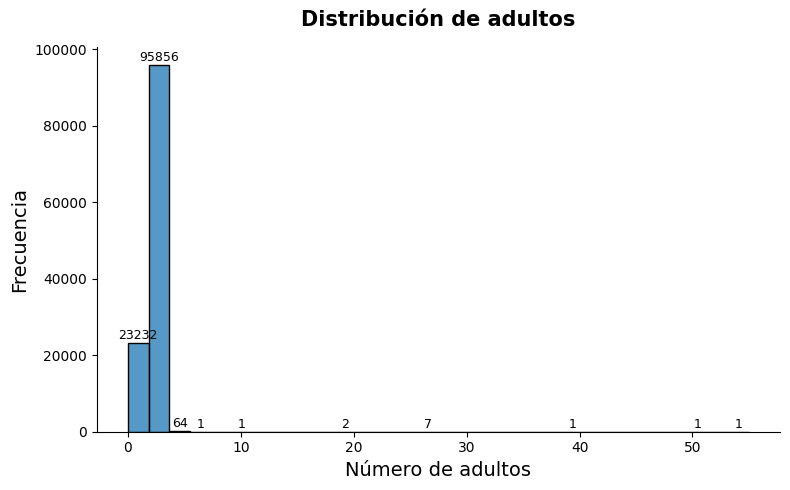

Número de reservas con más de 5 adultos: 14


In [ ]:
plot_histogram(data_clean, "adults", color=COLOR_NUMERICA, bins=30, kde=False, title="Distribución de adultos", xlabel="Número de adultos", ylabel="Frecuencia")


print("Número de reservas con más de 5 adultos:", data_clean[data_clean["adults"] > 5].shape[0])

data_clean = data_clean[data_clean["adults"] <= 5]
decisiones_limpieza_datos += "+   Se eliminaron las reservas con más de 5 adultos. \n   "


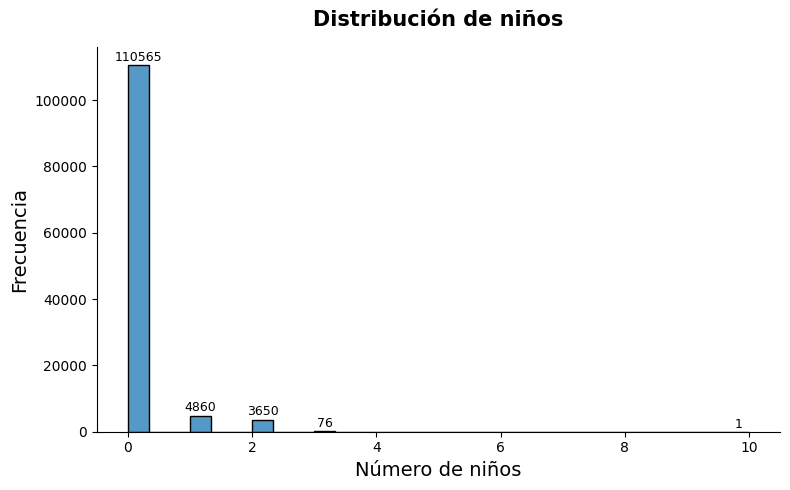

Número de reservas con más de 5 niños: 1


In [ ]:
plot_histogram(data_clean, "children", color=COLOR_NUMERICA, bins=30, kde=False, title="Distribución de niños", xlabel="Número de niños", ylabel="Frecuencia")

print("Número de reservas con más de 5 niños:", data_clean[data_clean["children"] > 5].shape[0])

data_clean = data_clean[data_clean["children"] <= 5]
decisiones_limpieza_datos += "+   Se eliminaron las reservas con más de 5 niños.  \n    "


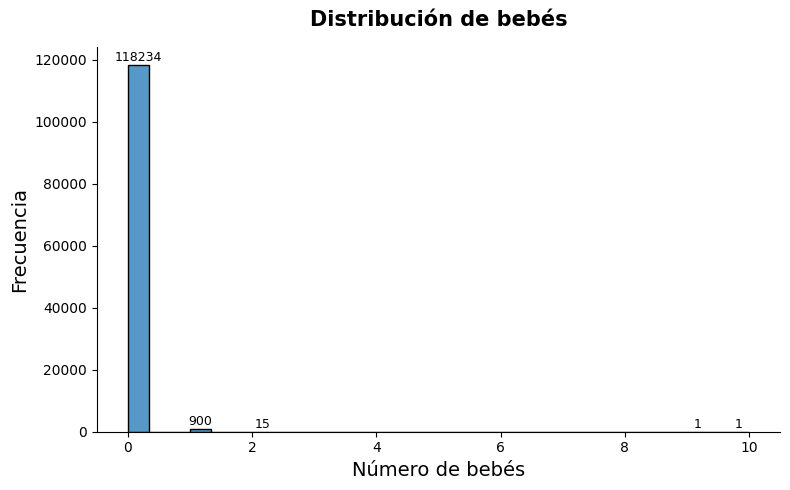

Número de reservas con más de 5 bebés: 2


In [ ]:
plot_histogram(data_clean, "babies", color=COLOR_NUMERICA, bins=30, kde=False, title="Distribución de bebés", xlabel="Número de bebés", ylabel="Frecuencia")


print("Número de reservas con más de 5 bebés:", data_clean[data_clean["babies"] > 5].shape[0])

data_clean = data_clean[data_clean["babies"] <= 5]
decisiones_limpieza_datos += "+   Se eliminaron las reservas con más de 5 bebés. \n    "

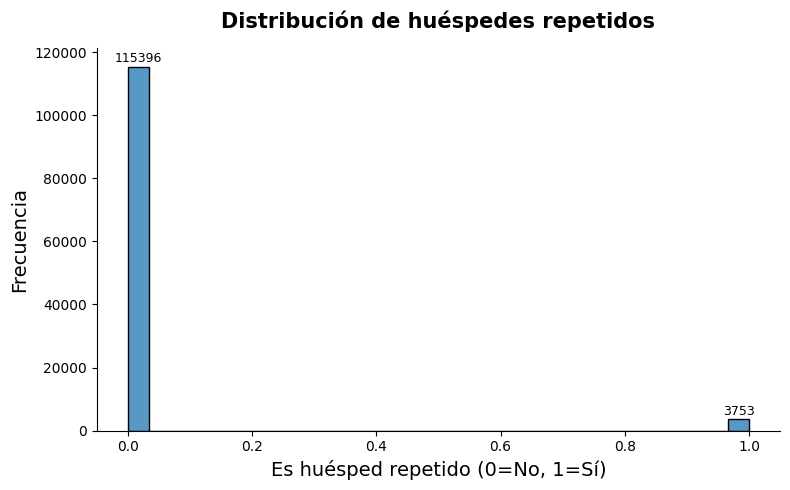

In [28]:
plot_histogram(data_clean, "is_repeated_guest", color=COLOR_NUMERICA, bins=30, kde=False, title="Distribución de huéspedes repetidos", xlabel="Es huésped repetido (0=No, 1=Sí)", ylabel="Frecuencia")

# Decision: nada por eliminar.

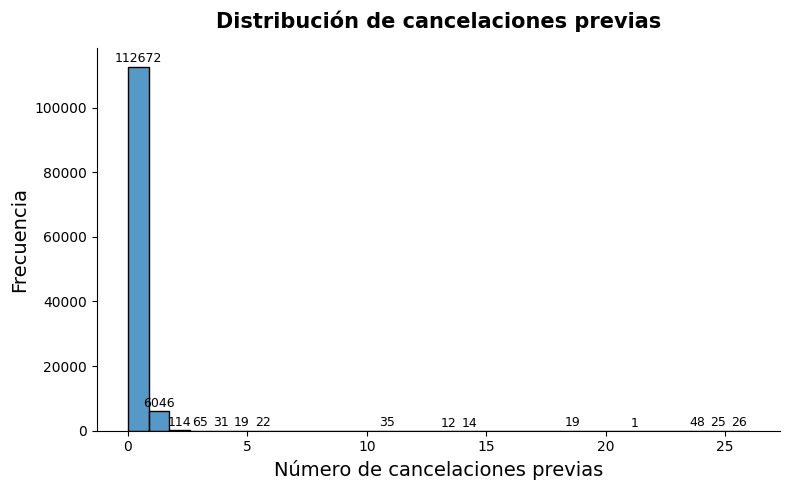

Número de reservas con más de 10 cancelaciones previas: 180


In [ ]:
plot_histogram(data_clean, "previous_cancellations", color=COLOR_NUMERICA, bins=30, kde=False, title="Distribución de cancelaciones previas", xlabel="Número de cancelaciones previas", ylabel="Frecuencia")


print("Número de reservas con más de 10 cancelaciones previas:", data_clean[data_clean["previous_cancellations"] > 10].shape[0])

data_clean = data_clean[data_clean["previous_cancellations"] <= 10]
decisiones_limpieza_datos += "+   Se eliminaron las reservas con más de 10 cancelaciones previas. \n    "



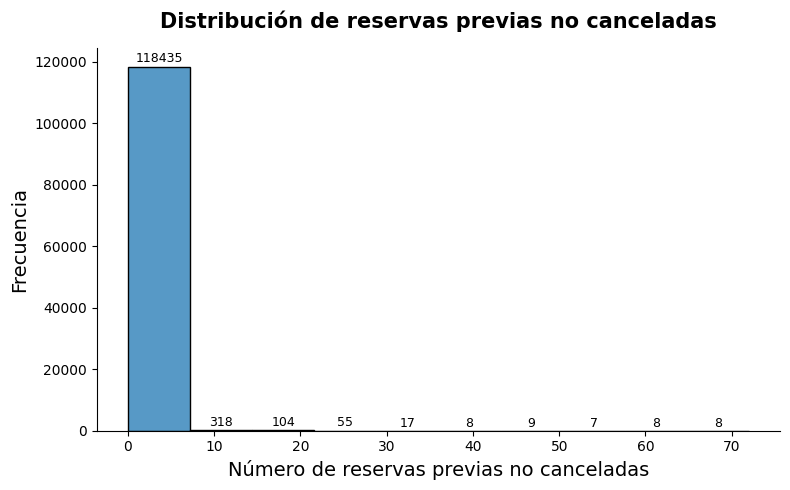

In [ ]:

plot_histogram(data_clean,  'previous_bookings_not_canceled', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de reservas previas no canceladas", xlabel="Número de reservas previas no canceladas", ylabel="Frecuencia")

#Decision: nada raro aca.

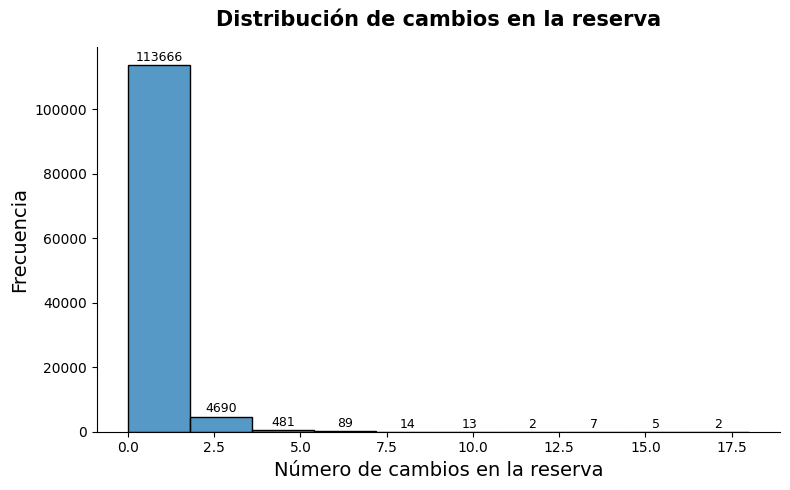

In [ ]:

plot_histogram(data_clean, 'booking_changes', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de cambios en la reserva", xlabel="Número de cambios en la reserva", ylabel="Frecuencia")

# decisión: nada raro aca.  

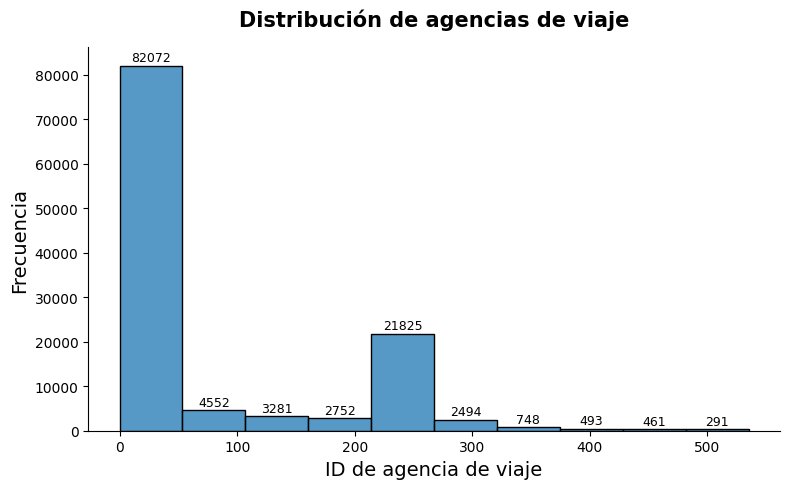

In [ ]:
# Agent = ID of the travel agency that made the booking
#IMPORTANTE:  ID es un numero, hay que convertir a categorica
plot_histogram(data_clean,  'agent', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de agencias de viaje", xlabel="ID de agencia de viaje", ylabel="Frecuencia")

# Decision: nada raro aca.

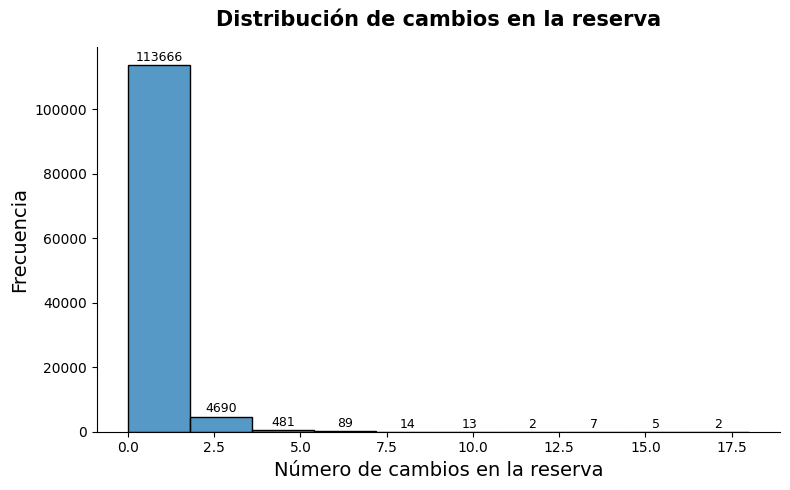

In [33]:
# Booking changes: El número de cambios realizados en la reserva. 
plot_histogram(data_clean,  'booking_changes', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de cambios en la reserva", xlabel="Número de cambios en la reserva", ylabel="Frecuencia")

# Decision:  nada raro aca.

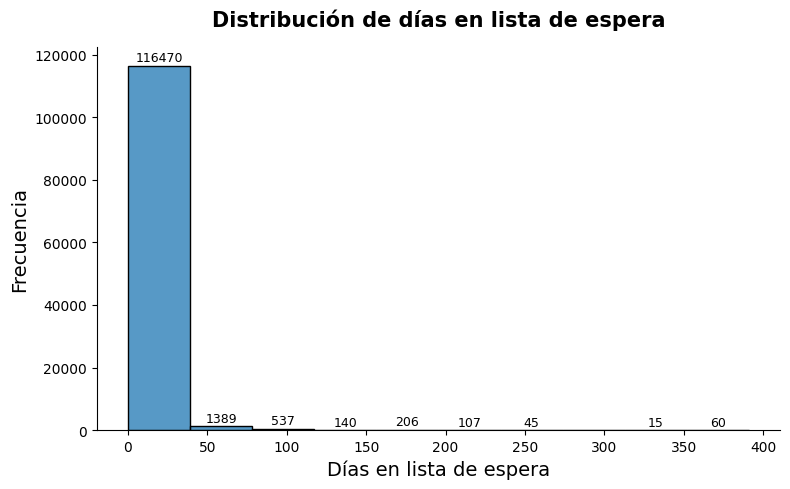

In [ ]:
plot_histogram(data_clean, 'days_in_waiting_list', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de días en lista de espera", xlabel="Días en lista de espera", ylabel="Frecuencia")    

# Decision: nada raro aca.


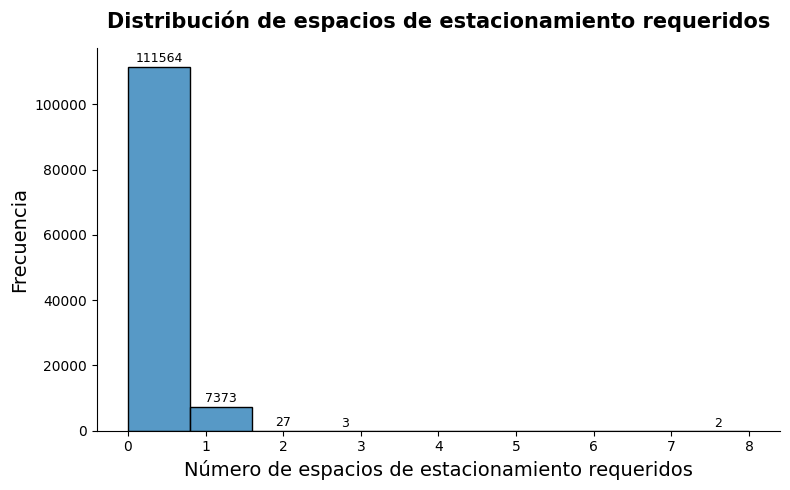

In [ ]:
plot_histogram(data_clean, 'required_car_parking_spaces', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de espacios de estacionamiento requeridos", xlabel="Número de espacios de estacionamiento requeridos", ylabel="Frecuencia")

# Decision: nada raro aca.

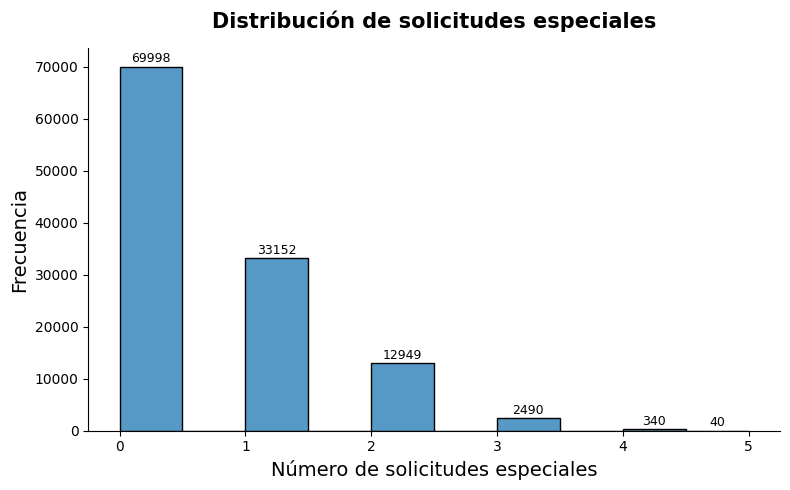

In [ ]:
plot_histogram(data_clean, 'total_of_special_requests', color=COLOR_NUMERICA, bins=10, kde=False, title="Distribución de solicitudes especiales", xlabel="Número de solicitudes especiales", ylabel="Frecuencia")

#Decisión: nada raro aca.


### Analisis univariado - Cualitativas


C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\2426236073.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


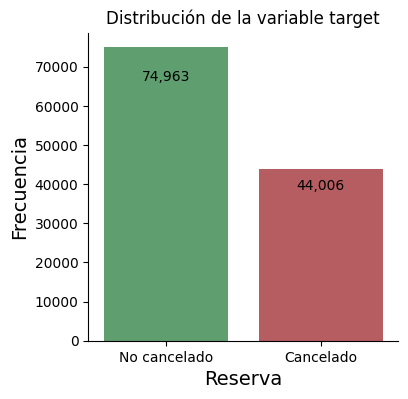

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("Figures/EDA", exist_ok=True)
plt.figure(figsize=(4,4))


ax = sns.countplot(
    data=data_clean,
    x='is_canceled',
    palette={
        "No cancelado": "#55A868", 
        "Cancelado": "#C44E52"})

sns.despine(ax=ax)
plt.title("Distribución de la variable target")
plt.xlabel("Reserva", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{int(h):,}', (p.get_x() + p.get_width()/2, h * 0.9),
                ha='center', va='center', color='black')

plt.savefig("Figures/EDA/05_Distribucion de la variable target.png",
            dpi=300, bbox_inches="tight")
plt.show()

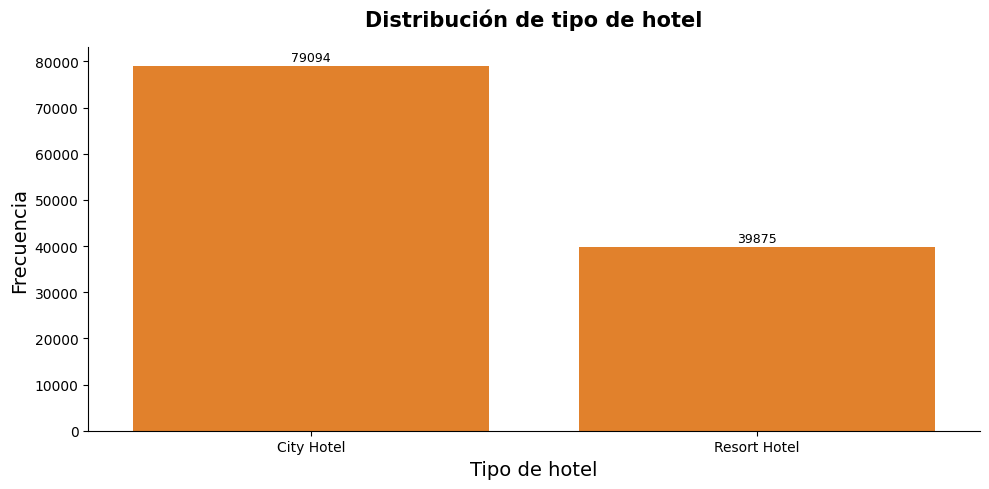

In [ ]:
plot_countplot(data_clean, 'hotel', color=COLOR_CATEGORICA, title="Distribución de tipo de hotel", xlabel="Tipo de hotel", ylabel="Frecuencia", xtick_rotation=0)

# Decisión: nada raro aca.

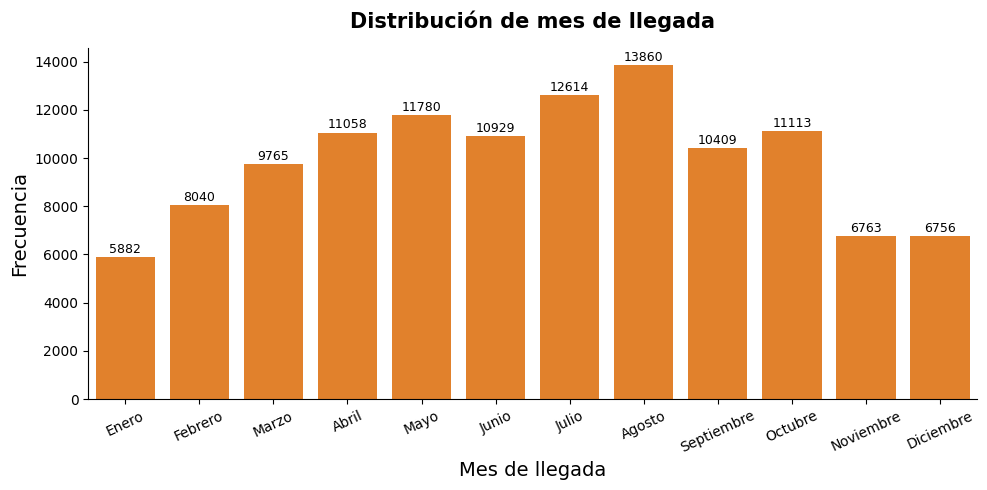

In [40]:
plot_countplot(data_clean, "arrival_date_month", color=COLOR_CATEGORICA, title="Distribución de mes de llegada", xlabel="Mes de llegada", ylabel="Frecuencia", order=["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio","Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"], xtick_rotation=25)


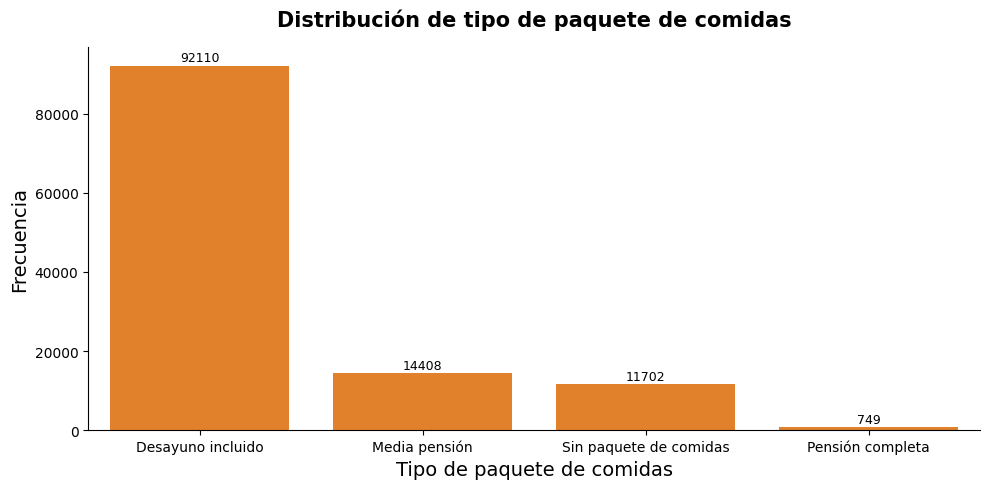

In [ ]:
plot_countplot(data_clean, 'meal', color=COLOR_CATEGORICA, title="Distribución de tipo de paquete de comidas", xlabel="Tipo de paquete de comidas", ylabel="Frecuencia", xtick_rotation=0)

# Decision: nada raro aca.

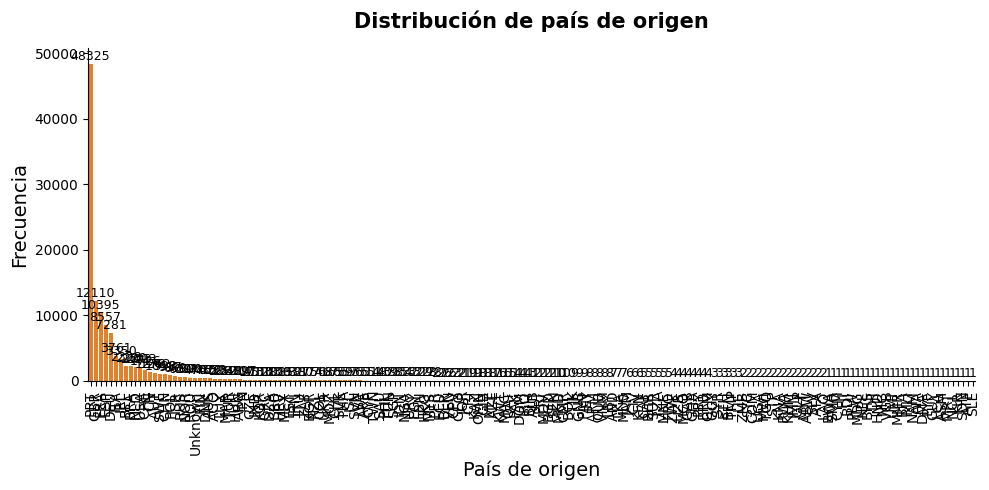

,country,count,country_name
0,PRT,48325,Portugal
1,GBR,12110,United Kingdom
2,FRA,10395,France
3,ESP,8557,Spain
4,DEU,7281,Germany
5,ITA,3761,Italy
6,IRL,3350,Ireland
7,BEL,2328,Belgium
8,BRA,2220,Brazil
9,NLD,2103,Netherlands


In [ ]:
plot_countplot(data_clean, "country", color=COLOR_CATEGORICA, title="Distribución de país de origen", xlabel="País de origen", ylabel="Frecuencia", xtick_rotation=90)

import pandas as pd
import pycountry
pd.set_option('display.max_rows', None)

df_country = data_clean["country"].value_counts().reset_index()
df_country.columns = ["country", "count"]

def get_country_name(code):
    try:
        return pycountry.countries.get(alpha_3=code).name
    except:
        return None

df_country["country_name"] = df_country["country"].apply(get_country_name)

df_country



# Decision: nada raro aca.



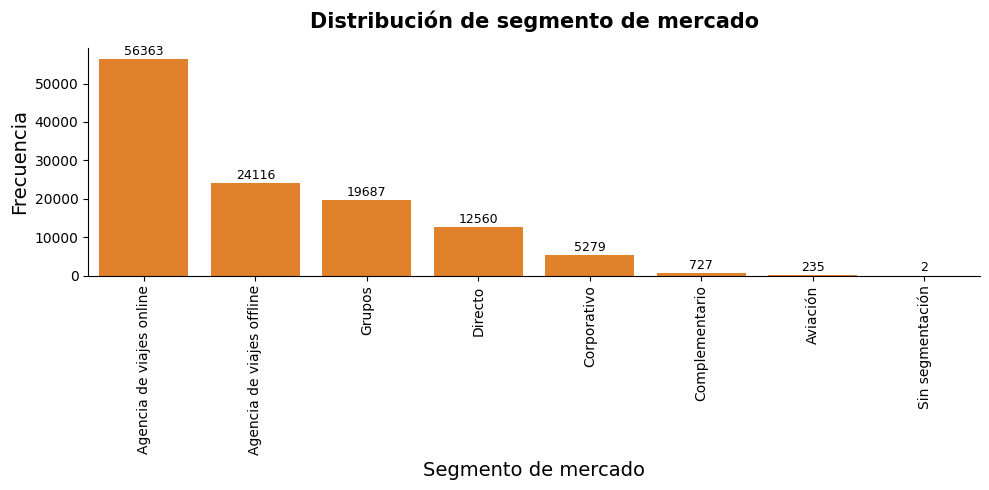

In [ ]:
plot_countplot(data_clean,  'market_segment', color=COLOR_CATEGORICA, title="Distribución de segmento de mercado", xlabel="Segmento de mercado", ylabel="Frecuencia", xtick_rotation=90)

#Decision: nada raro aca.

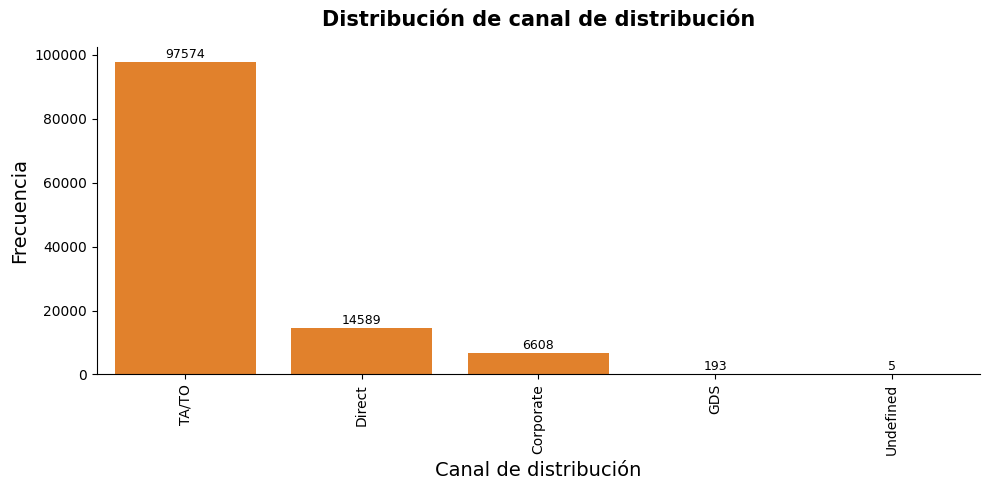

In [ ]:
plot_countplot(data_clean,  'distribution_channel', color=COLOR_CATEGORICA, title="Distribución de canal de distribución", xlabel="Canal de distribución", ylabel="Frecuencia", xtick_rotation=90)

# Decision: nada raro aca.

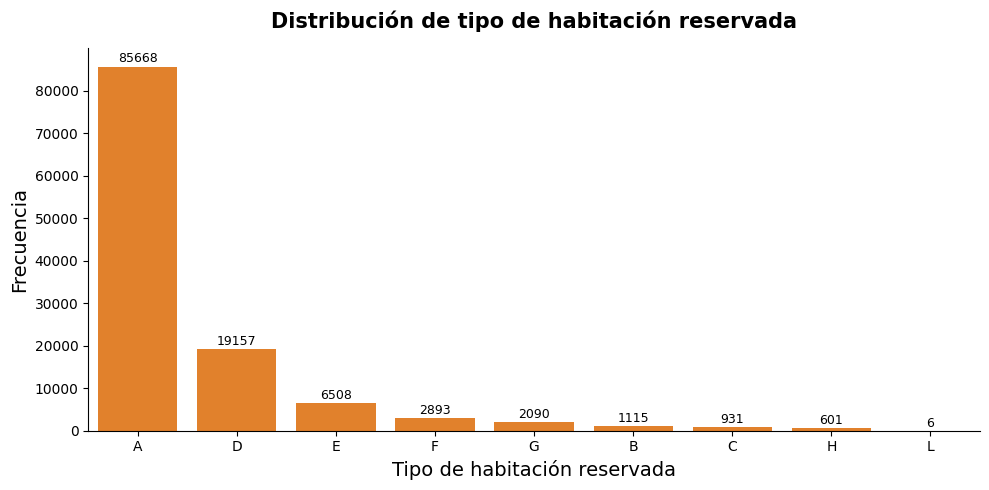

In [ ]:
plot_countplot(data_clean, 'reserved_room_type', color=COLOR_CATEGORICA, title="Distribución de tipo de habitación reservada", xlabel="Tipo de habitación reservada", ylabel="Frecuencia", xtick_rotation=0)

#Decision: nada raro aca.

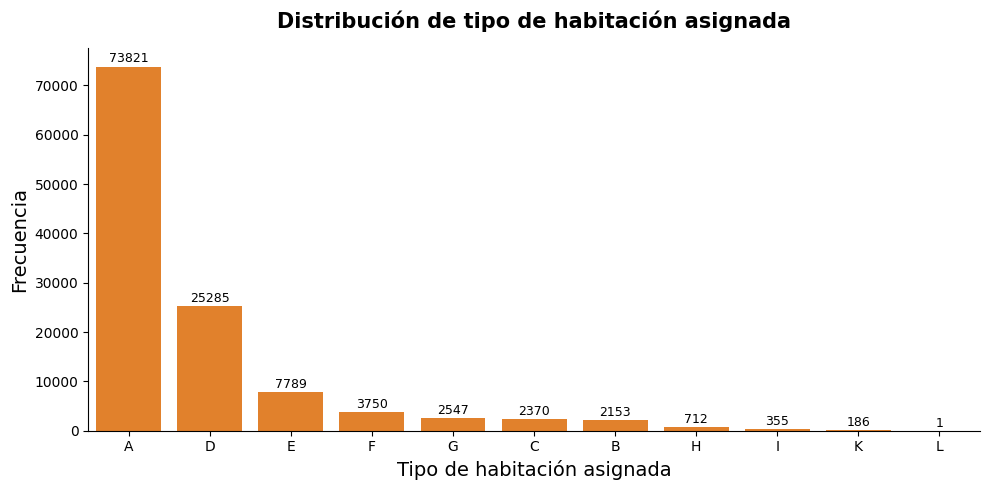

In [ ]:
plot_countplot(data_clean, 'assigned_room_type', color=COLOR_CATEGORICA, title="Distribución de tipo de habitación asignada", xlabel="Tipo de habitación asignada", ylabel="Frecuencia", xtick_rotation=0)

#decision: nada raro aca.

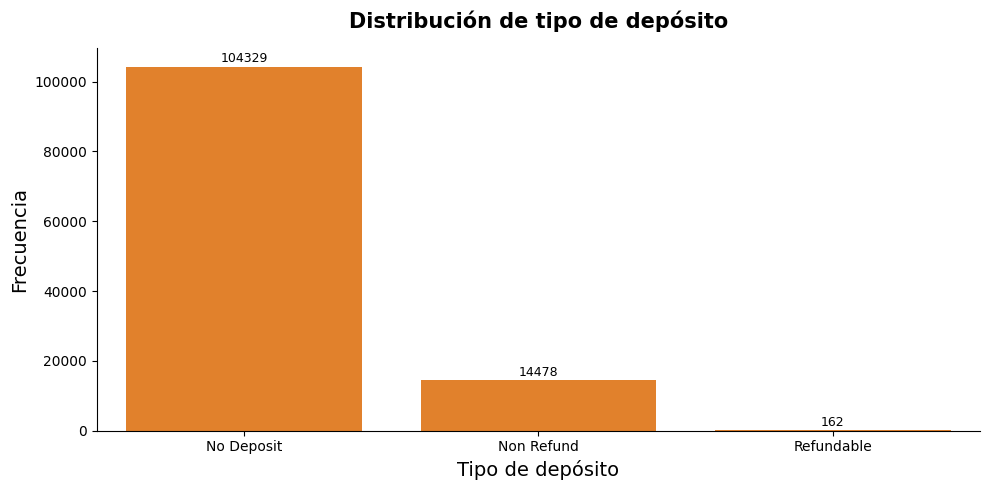

In [ ]:
plot_countplot(data_clean, 'deposit_type', color=COLOR_CATEGORICA, title="Distribución de tipo de depósito", xlabel="Tipo de depósito", ylabel="Frecuencia", xtick_rotation=0)

# Decision: nada raro aca.

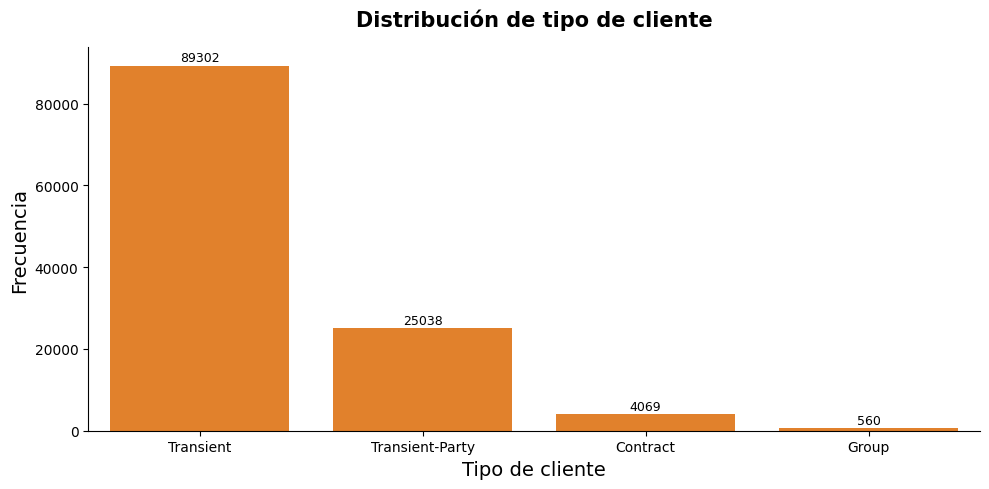

In [ ]:
plot_countplot(data_clean, 'customer_type', color=COLOR_CATEGORICA, title="Distribución de tipo de cliente", xlabel="Tipo de cliente", ylabel="Frecuencia", xtick_rotation=0)

#Decision: nada raro aca.


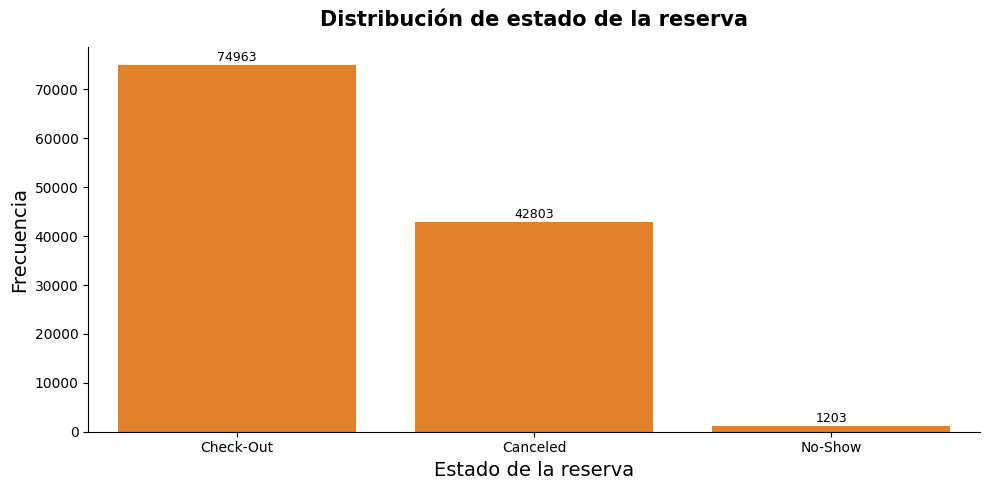

In [ ]:
plot_countplot(data_clean, 'reservation_status', color=COLOR_CATEGORICA, title="Distribución de estado de la reserva", xlabel="Estado de la reserva", ylabel="Frecuencia", xtick_rotation=0)

#Decision: nada raro aca.

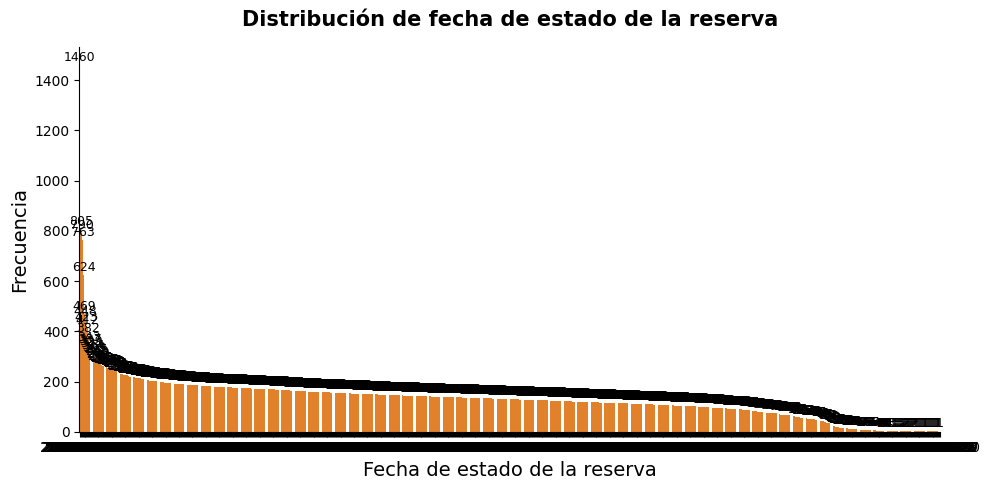

In [ ]:
plot_countplot(data_clean, 'reservation_status_date', color=COLOR_CATEGORICA, title="Distribución de fecha de estado de la reserva", xlabel="Fecha de estado de la reserva", ylabel="Frecuencia", xtick_rotation=0)

#Decision: nada raro aca.

## Resumen de univariada

In [ ]:
# Shape del dataframe al inicio
print(f"Shape del dataset después de la limpieza univariada: {data.shape}")
# Shape del dataframe al final
print(f"Shape del dataset después de la limpieza univariada: {data_clean.shape}")
# Filas descsartadas:
filas_descartadas = data.shape[0] - data_clean.shape[0]
print(f"Filas descartadas: {filas_descartadas}")    
#Decisiones tomadas
print(decisiones_limpieza_datos)

Shape del dataset después de la limpieza univariada: (119390, 32)
Shape del dataset después de la limpieza univariada: (118969, 31)
Filas descartadas: 421
Se reemplazaron los valores faltantes de las siguientes columnas: children, country, agent . Se asumió que si no hay valor en children, entonces no hay niños; si no hay valor en country, entonces el país es desconocido; y si no hay valor en agent  entonces la reserva fue hecha sin agencia o por un cliente privado respectivamente. 
  
+   Se eliminó la columna company debido a la gran cantidad de valores faltantes. 
cuantos eran? eran 0.943068933746545      
 +   Se eliminaron las reservas que no tenían ningún huésped (0 adultos, 0 niños y 0 bebés), ya que no son casos válidos para el análisis. 
 +   Se eliminaron las filas duplicadas que se repetían más de 10 veces, ya que podrían ser errores o casos atípicos.  Este valor fue estimado por el grafico, no sale de bilbiografia ni nada. Se mantuvieron las filas que se repetían hasta 10 v

# EDA con insights

### Proporcion de cancelacion en cada tipo de hotel

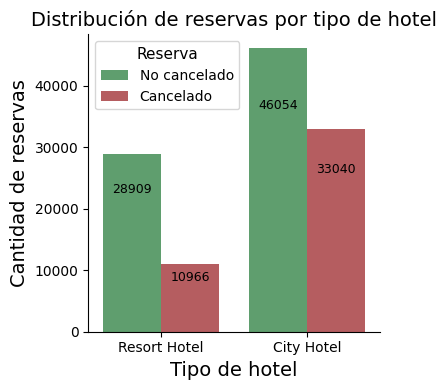

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,4))

ax = sns.countplot(
    data=data_clean,
    x='hotel',
    hue='is_canceled',
    palette={"No cancelado": "#55A868", "Cancelado": "#C44E52"}
)

plt.title("Distribución de reservas por tipo de hotel", fontsize=14)

plt.xlabel("Tipo de hotel", fontsize=14)
plt.ylabel("Cantidad de reservas", fontsize=14)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.legend(title="Reserva", fontsize=10, title_fontsize=11)

# 🔥 AGREGAR VALORES EN CADA BARRA
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        ax.annotate(
            f'{int(h)}',
            (bar.get_x() + bar.get_width()/2, h * 0.8),
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )
sns.despine()
plt.tight_layout()

plt.savefig(os.path.join(eda_path, "06_Con insight_Cancelaciones por hotel.png"),
            bbox_inches='tight', dpi=300)

plt.show()

### Cancelaciones por estacionalidad (mes de llegada)

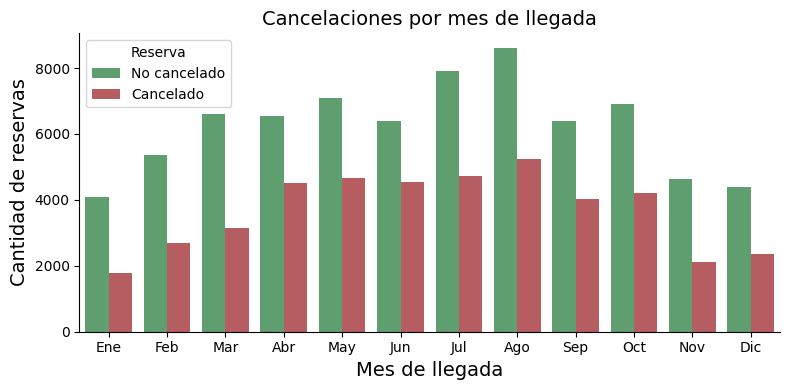

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

meses_completos = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                   'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
meses_abreviados = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(8,4))
sns.countplot(data=data_clean, x='arrival_date_month', hue='is_canceled',
              palette={"No cancelado": "#55A868", "Cancelado": "#C44E52"},
              order=meses_completos)

plt.xlabel("Tipo de hotel", fontsize=14)
plt.ylabel("Cantidad de reservas", fontsize=14)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.title("Cancelaciones por mes de llegada", fontsize=14)
plt.xlabel("Mes de llegada")
plt.ylabel("Cantidad de reservas")
plt.legend(title="Reserva")
plt.xticks(ticks=range(len(meses_abreviados)), labels=meses_abreviados)
sns.despine() 
plt.tight_layout()
plt.savefig(os.path.join(eda_path, "07_Con insight_Estacionalidad de cancelaciones.png"), bbox_inches='tight', dpi=300)



### Cancelaciones por segmento de mercado

C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\3802081780.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


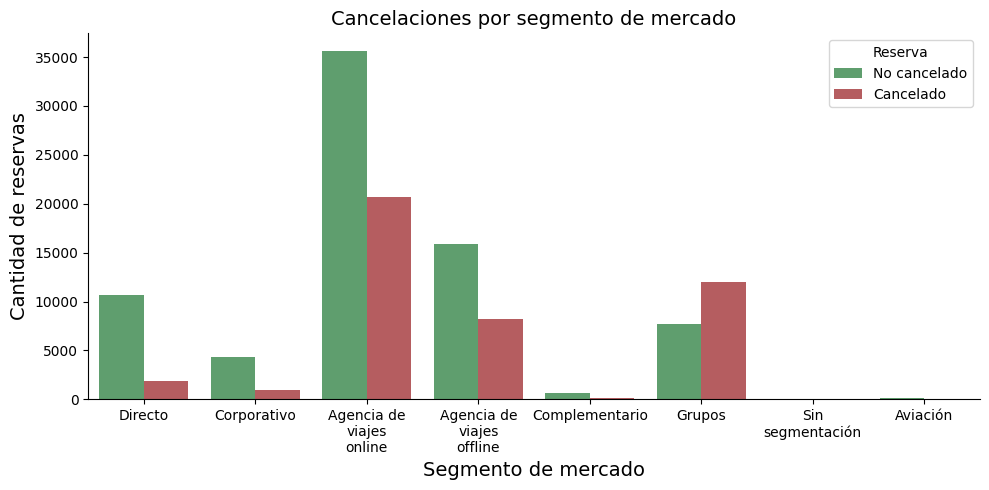

In [ ]:
import textwrap

plt.figure(figsize=(10,5))
ax = sns.countplot(
    data=data_clean,
    x='market_segment',
    hue='is_canceled',
    palette={"No cancelado": "#55A868", "Cancelado": "#C44E52"}
)

import textwrap

labels = [
    textwrap.fill(
        label.get_text(),
        width=10,
        break_long_words=False,
        break_on_hyphens=False
    )
    for label in ax.get_xticklabels()
]

ax.set_xticklabels(labels)
plt.xlabel("Tipo de hotel", fontsize=14)
plt.ylabel("Cantidad de reservas", fontsize=14)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.title("Cancelaciones por segmento de mercado", fontsize=14)
plt.xlabel("Segmento de mercado")
plt.ylabel("Cantidad de reservas")
plt.legend(title="Reserva")
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(eda_path, "08_Con insight_Cancelaciones segun el segmento de mercado.png"), bbox_inches='tight', dpi=300)


### Clientes y los paises de los que provienen

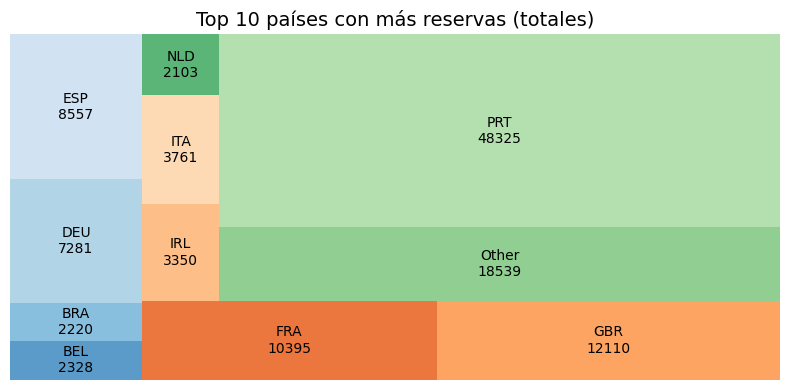

In [ ]:

country_counts = data_clean["country"].value_counts().reset_index()
country_counts.columns = ["country", "Number of Guests"]


top_n = 10
top_countries = country_counts.head(top_n)["country"].tolist()

country_counts["country_grouped"] = country_counts["country"].apply(lambda x: x if x in top_countries else "Other")

country_grouped = (country_counts.groupby("country_grouped", as_index=False).agg({"Number of Guests": "sum"}))

plt.figure(figsize=(8, 4))
colors = plt.cm.tab20c.colors  

squarify.plot(sizes=country_grouped["Number of Guests"], label=country_grouped["country_grouped"] + "\n" + country_grouped["Number of Guests"].astype(str),alpha=0.8,color=colors)
plt.axis('off')
plt.title(f"Top {top_n} países con más reservas (totales)", fontsize=14)
plt.tight_layout()

os.makedirs(eda_path, exist_ok=True)
filename = os.path.join(eda_path, "09_Con insight_Top 10 paises.png")
plt.savefig(filename, bbox_inches='tight', dpi=300)

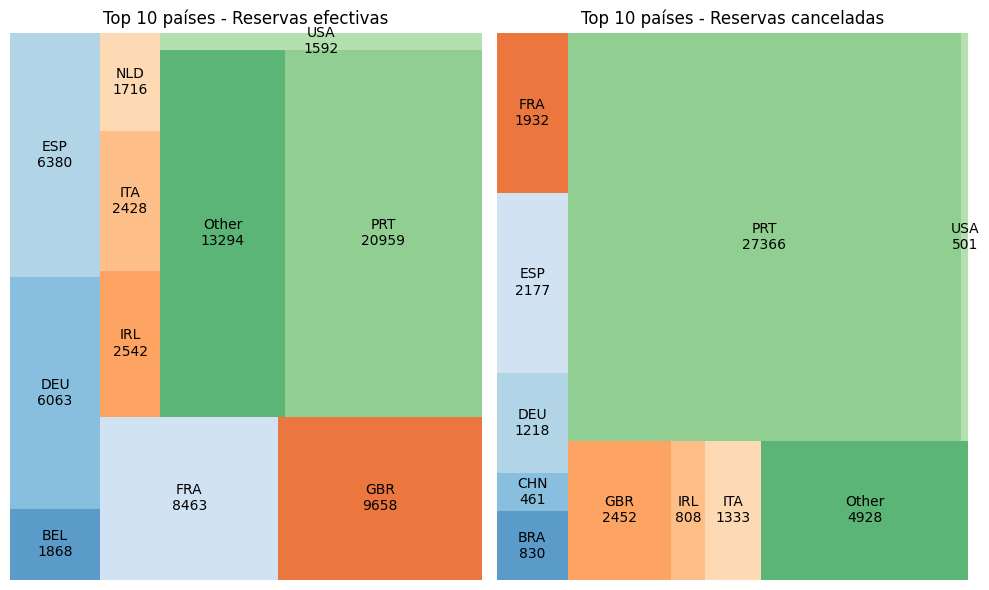

In [ ]:
import os
import matplotlib.pyplot as plt
import squarify
import pandas as pd

top_n = 10

df_no_cancel = data_clean[data_clean["is_canceled"].isin([0, "No cancelado"])]
df_cancel = data_clean[data_clean["is_canceled"].isin([1, "Cancelado"])]

def prepare_treemap_df(df, top_n=10):
    counts = df["country"].value_counts().reset_index()
    counts.columns = ["country", "Number of Guests"]
    top_countries = counts.head(top_n)["country"].tolist()
    counts["country_grouped"] = counts["country"].apply(lambda x: x if x in top_countries else "Other")
    df_grouped = counts.groupby("country_grouped", as_index=False).agg({"Number of Guests": "sum"})
    return df_grouped

df_no_cancel_grouped = prepare_treemap_df(df_no_cancel, top_n)
df_cancel_grouped = prepare_treemap_df(df_cancel, top_n)

colors = plt.cm.tab20c.colors

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
squarify.plot(
    sizes=df_no_cancel_grouped["Number of Guests"],
    label=df_no_cancel_grouped["country_grouped"] + "\n" + df_no_cancel_grouped["Number of Guests"].astype(str),
    alpha=0.8,
    color=colors,
    ax=axes[0]
)
axes[0].axis("off")
axes[0].set_title(f"Top {top_n} países - Reservas efectivas")


squarify.plot(
    sizes=df_cancel_grouped["Number of Guests"],
    label=df_cancel_grouped["country_grouped"] + "\n" + df_cancel_grouped["Number of Guests"].astype(str),
    alpha=0.8,
    color=colors,
    ax=axes[1]
)
axes[1].axis("off")
axes[1].set_title(f"Top {top_n} países - Reservas canceladas")

plt.tight_layout()
# Guardar figura
os.makedirs(eda_path, exist_ok=True)
plt.savefig(os.path.join(eda_path, "09_Con insight_BIS Top10 paises cancel vs noCancel.png"), bbox_inches='tight', dpi=300)

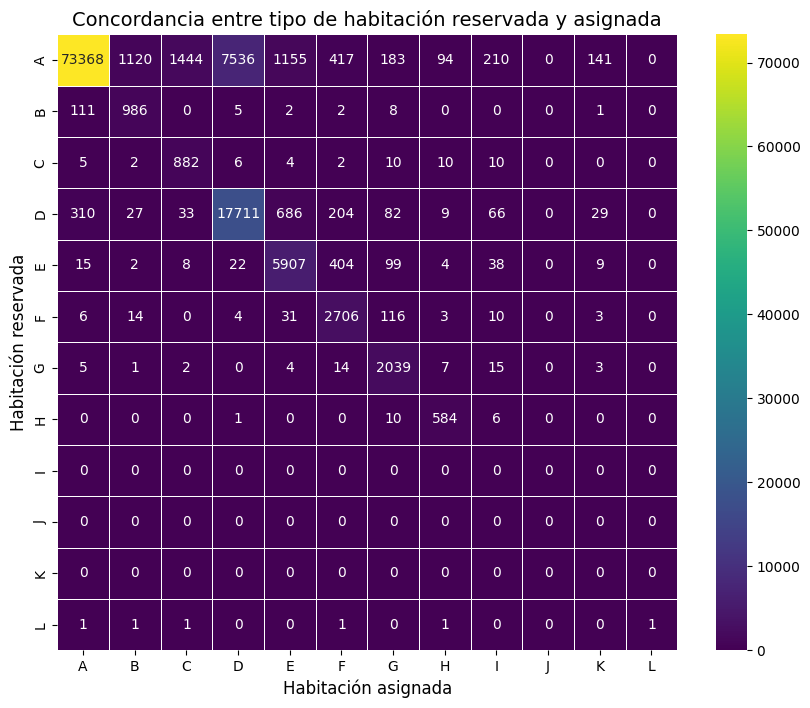

In [ ]:

import string
df= data_clean.copy()
categorias = list(string.ascii_uppercase[:12])  # A–L

matriz = pd.crosstab(df['reserved_room_type'], df['assigned_room_type'])

matriz = matriz.reindex(index=categorias, columns=categorias, fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='viridis', linewidths=0.5, linecolor='white')

plt.title('Concordancia entre tipo de habitación reservada y asignada', fontsize=14)
plt.xlabel('Habitación asignada', fontsize=12)
plt.ylabel('Habitación reservada', fontsize=12)

output_path = os.path.join(eda_path, "010_Con insight_Matcheo entre roop type asignada y reservada heatmap.png")
plt.savefig(output_path, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import string


categorias = list(string.ascii_uppercase[:12])


matriz = pd.crosstab(df['reserved_room_type'], df['assigned_room_type'])
matriz = matriz.reindex(index=categorias, columns=categorias, fill_value=0)


total_reservas = matriz.values.sum()

correctas = np.trace(matriz.values)
pct_correctas = correctas / total_reservas * 100


arriba_diag = np.triu(matriz.values, k=1).sum()
pct_arriba = arriba_diag / total_reservas * 100

debajo_diag = np.tril(matriz.values, k=-1).sum()
pct_debajo = debajo_diag / total_reservas * 100

print(" En la lógica de este dataset hotelero, generalmente se interpreta que las room types están ordenadas alfabéticamente según nivel de categoría o calidad. \
         A → mejor habitación o más premium \
         B → menos premium \
…y así sucesivamente hasta L → categoría más básica o económica") 

print(f"Porcentaje correctamente asignadas (diagonal): {pct_correctas:.2f}%")
print(f"Porcentaje asignadas arriba de la diagonal (upgrade): {pct_arriba:.2f}%")
print(f"Porcentaje asignadas debajo de la diagonal (downgrade): {pct_debajo:.2f}%")



 En la lógica de este dataset hotelero, generalmente se interpreta que las room types están ordenadas alfabéticamente según nivel de categoría o calidad.          A → mejor habitación o más premium          B → menos premium …y así sucesivamente hasta L → categoría más básica o económica
Porcentaje correctamente asignadas (diagonal): 87.57%
Porcentaje asignadas arriba de la diagonal (upgrade): 11.90%
Porcentaje asignadas debajo de la diagonal (downgrade): 0.53%


C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\3770830290.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_clean, x='is_canceled', y='lead_time',
C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\3770830290.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


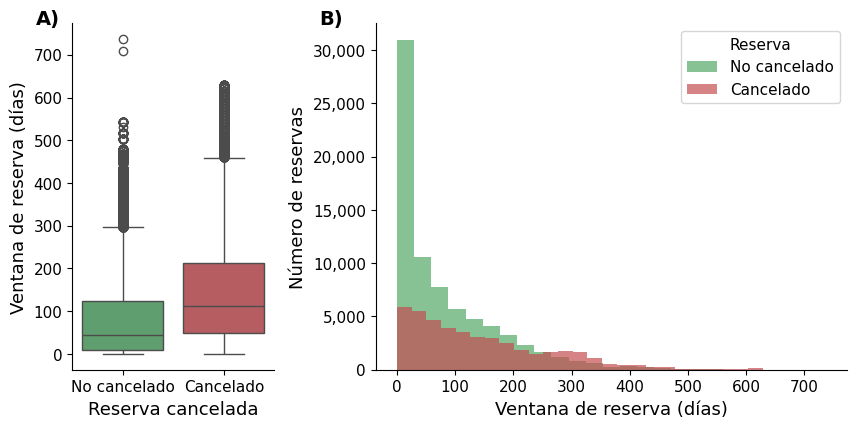

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

palette_manual = {"No cancelado": "#55A868", "Cancelado": "#C44E52"}

fig = plt.figure(figsize=(10, 4.5))

gs = gridspec.GridSpec(1, 2, width_ratios=[0.3, 0.7], wspace=0.3)

ax0 = fig.add_subplot(gs[0])
sns.boxplot(data=data_clean, x='is_canceled', y='lead_time',
            palette=palette_manual, ax=ax0)
ax0.set(xlabel="Reserva cancelada", ylabel="Ventana de reserva (días)")
ax0.xaxis.label.set_size(13)
ax0.yaxis.label.set_size(13)
ax0.tick_params(labelsize=11)
ax0.text(-0.18, 1.04, "A)", transform=ax0.transAxes,
         fontsize=14, fontweight='bold', va='top')

ax1 = fig.add_subplot(gs[1])
for status, color in palette_manual.items():
    ax1.hist(data_clean[data_clean['is_canceled'] == status]['lead_time'],
             bins=25, alpha=0.7, label=status, color=color)
ax1.set(xlabel="Ventana de reserva (días)", ylabel="Número de reservas")
ax1.xaxis.label.set_size(13)
ax1.yaxis.label.set_size(13)
ax1.tick_params(labelsize=11)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.legend(title="Reserva", fontsize=11, title_fontsize=11)
ax1.text(-0.12, 1.04, "B)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold', va='top')

sns.despine()
plt.tight_layout()

plt.savefig(os.path.join(eda_path,
            "011_Con_insight_Cancelaciones_tiempo_antelacion.png"),
            bbox_inches='tight', dpi=300)
plt.show()


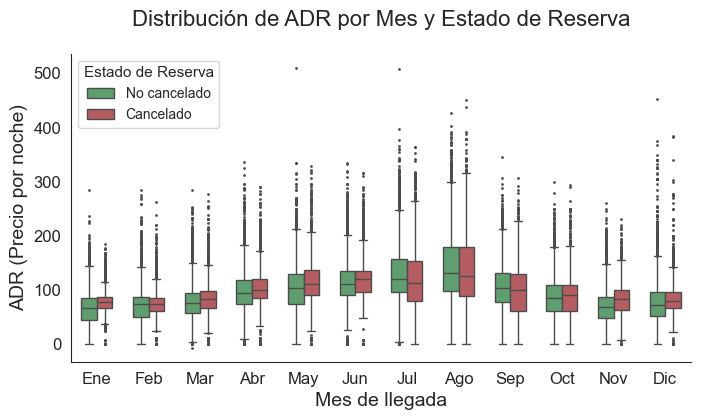

In [ ]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os


df_plot = data_clean.copy()
dict_meses = {'Enero':'Ene','Febrero':'Feb','Marzo':'Mar','Abril':'Abr','Mayo':'May','Junio':'Jun',
              'Julio':'Jul','Agosto':'Ago','Septiembre':'Sep','Octubre':'Oct','Noviembre':'Nov','Diciembre':'Dic'}
df_plot['arrival_date_month'] = df_plot['arrival_date_month'].map(dict_meses)
meses_orden = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

palette_manual = {"No cancelado": "#55A868", "Cancelado": "#C44E52"}


sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 4)) 

sns.boxplot(
    data=df_plot, 
    x='arrival_date_month', 
    y='adr', 
    hue='is_canceled', 
    order=meses_orden, 
    palette=palette_manual,
    fliersize=1,  
    width=0.6,    
    ax=ax
)

ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel('Mes de llegada', fontsize=14)
ax.set_ylabel('ADR (Precio por noche)', fontsize=14)
ax.set_title('Distribución de ADR por Mes y Estado de Reserva', fontsize=16, pad=20)
ax.legend(title='Estado de Reserva', fontsize=10, title_fontsize=11)
sns.despine()


os.makedirs('Figures/EDA', exist_ok=True)
plt.savefig('Figures/EDA/012_Temporalidad de ingresos y perdidas de oportunidad.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

ingreso_real = df_plot[df_plot['is_canceled'] == 'No cancelado']['adr'].sum()
ingreso_perdido = df_plot[df_plot['is_canceled'] == 'Cancelado']['adr'].sum()
ingreso_total_potencial = ingreso_real + ingreso_perdido

print(f"--- Análisis Financiero ---")
print(f"Ingresos Reales (No cancelados):  ${ingreso_real:,.2f}")
print(f"Ingresos Perdidos (Cancelados):   ${ingreso_perdido:,.2f}")
print(f"--------------------------------")
print(f"Ingreso Total Potencial:          ${ingreso_total_potencial:,.2f}")
print(f"Porcentaje de pérdida:            {(ingreso_perdido / ingreso_total_potencial) * 100:.2f}%")


--- Análisis Financiero ---
Ingresos Reales (No cancelados):  $7,510,593.80
Ingresos Perdidos (Cancelados):   $4,625,409.04
--------------------------------
Ingreso Total Potencial:          $12,136,002.84
Porcentaje de pérdida:            38.11%


# Conversion de datatypes y guardado de data clean.
Segun dicc de datos

In [ ]:
#Seteo el tipo de dato segun el diccionario de datos. Primero las categoricas.
cols_categoricas = [
    "is_canceled","arrival_date_month","agent",
    "assigned_room_type","country","customer_type","deposit_type",
    "distribution_channel","is_repeated_guest","market_segment",
    "reservation_status","reserved_room_type"
]

data_clean[cols_categoricas] = data_clean[cols_categoricas].astype("category")

# Luego convierto el resto de las variables a numerica integer salvo ADR que es numerica float y ReservationStatusDate es date. 
cols_numericas = [
    "adults","babies","booking_changes","children",
    "days_in_waiting_list","lead_time","previous_bookings_not_canceled",
    "previous_cancellations","required_car_parking_spaces",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]   
data_clean[cols_numericas] = data_clean[cols_numericas].astype("int")
data_clean["adr"] = data_clean["adr"].astype("float")
data_clean["reservation_status_date"] = pd.to_datetime(data_clean["reservation_status_date"])


In [63]:
# Guardo el dataset limpio para el modelado.
output_path = os.path.join(data_path, "hotel_booking_clean.csv")
data_clean.to_csv(output_path, index=False)

# Dropeo de variables por data leakage o bien resignificacion de variables.

C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\1644512407.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="RdBu_r")


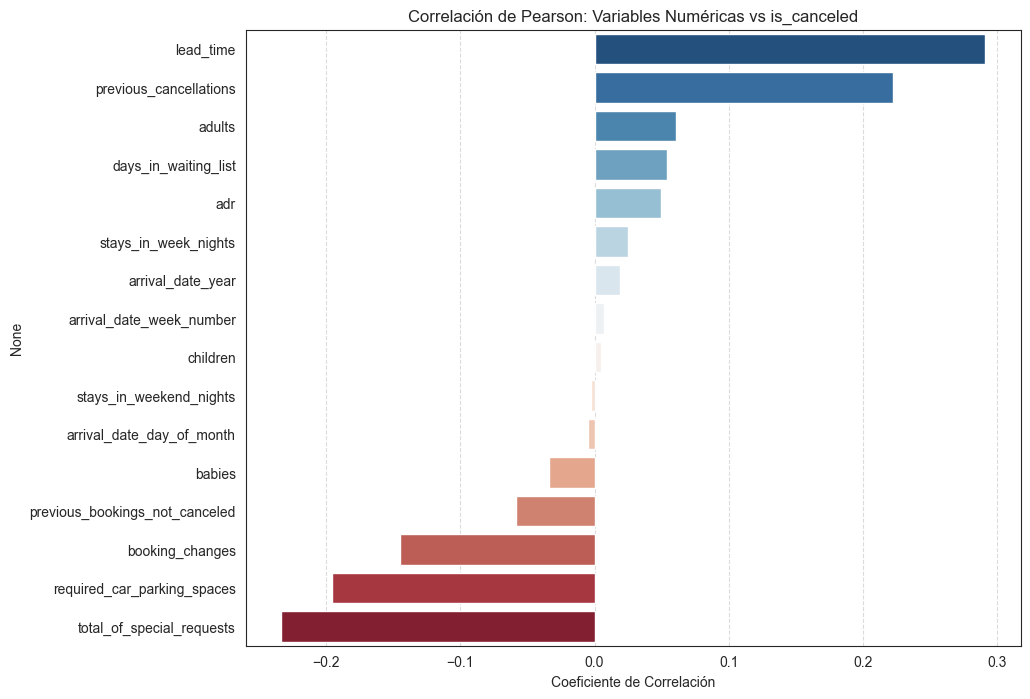

C:\Users\yair.barnatan\AppData\Local\Temp\ipykernel_24780\1644512407.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vars_categorical = data_clean.select_dtypes(include=['object', 'category']).columns.tolist()


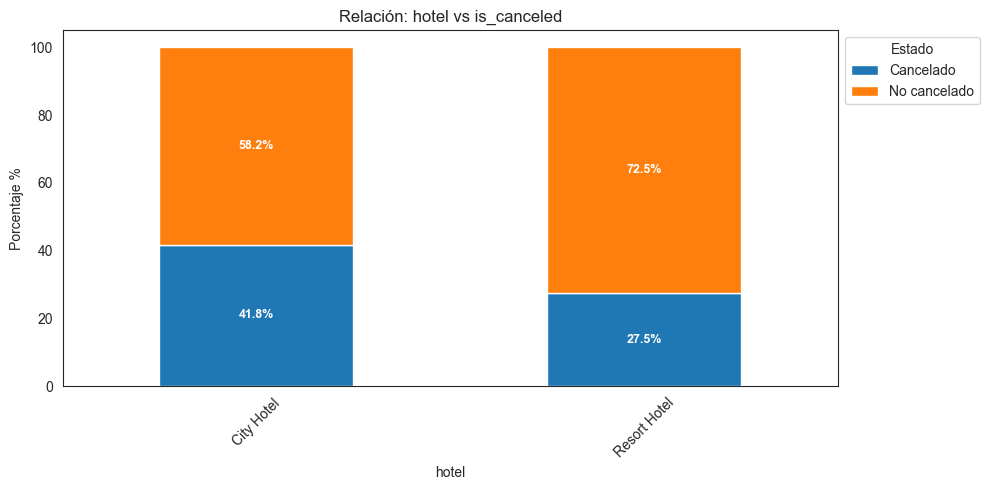

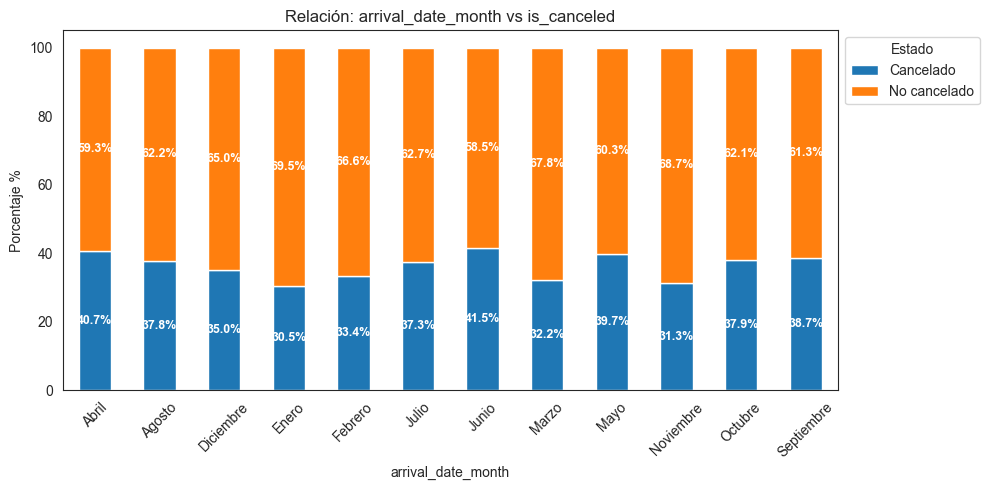

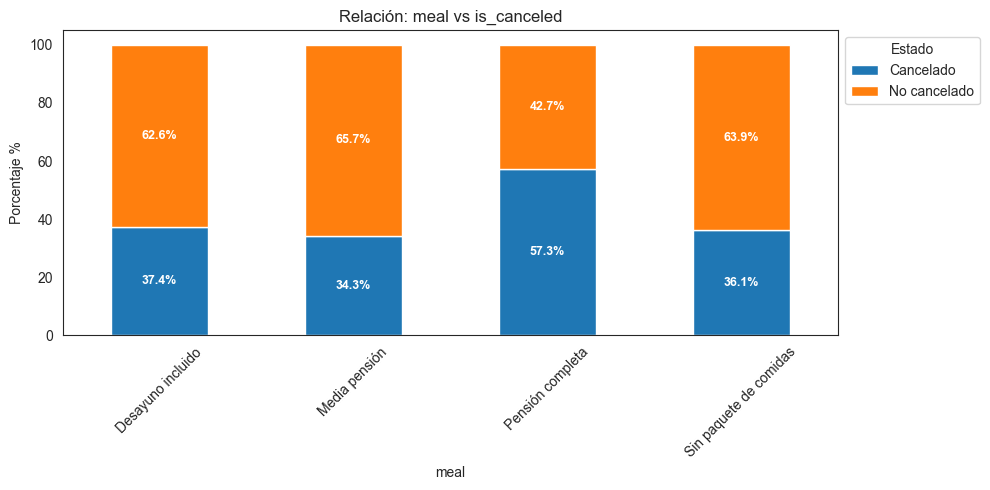

Saltando country: Alta cardinalidad (178 categorías)


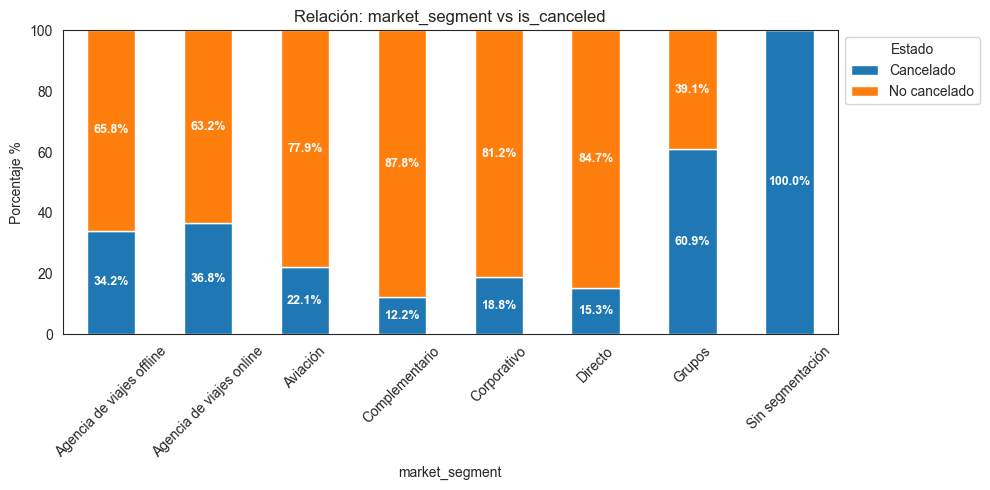

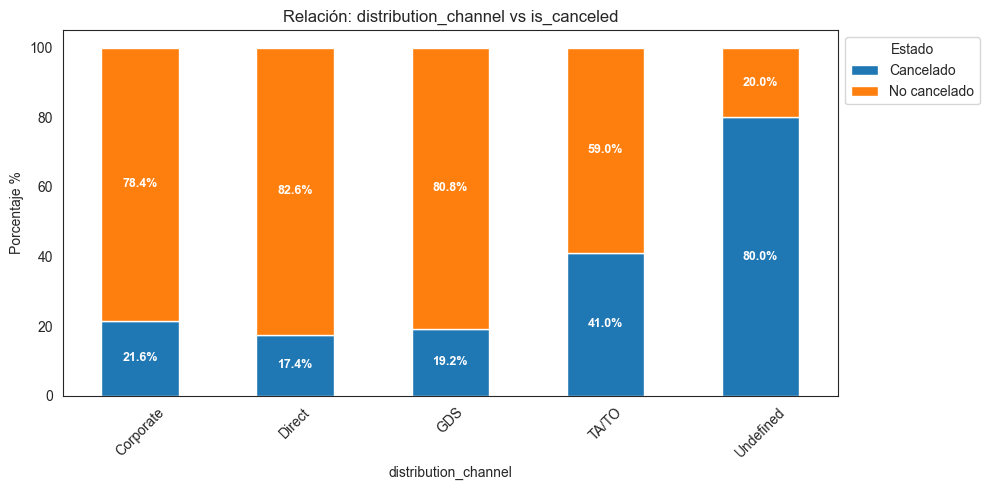

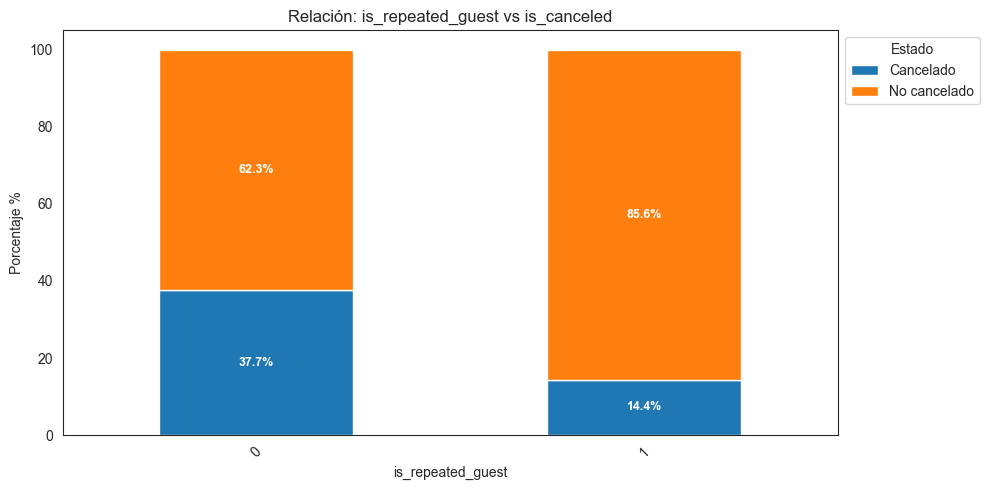

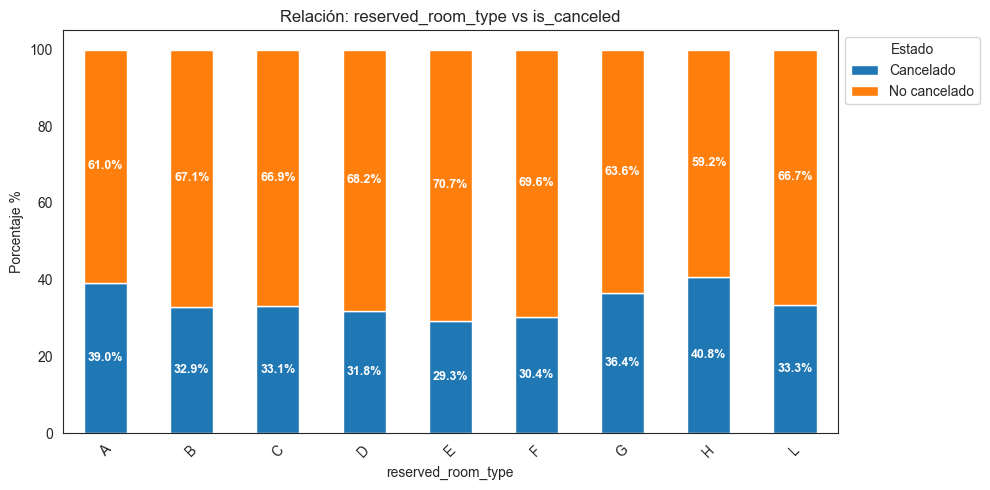

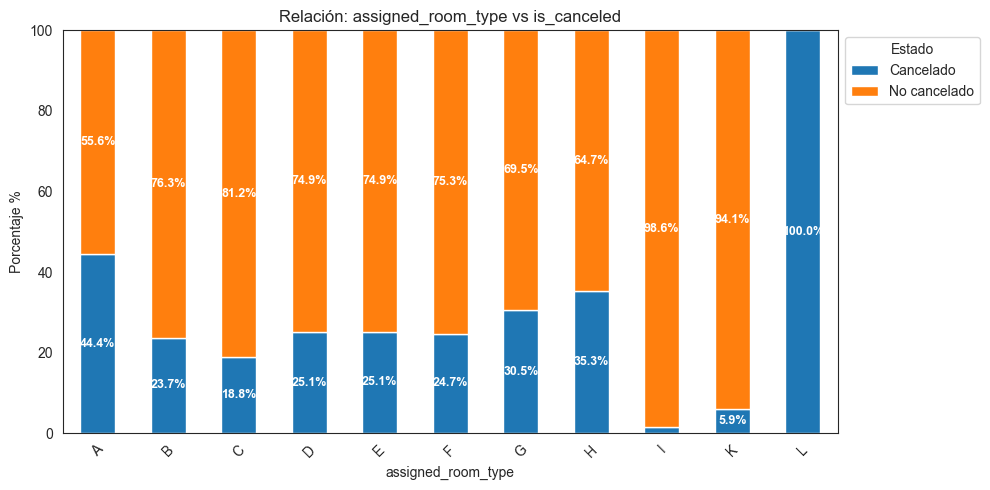

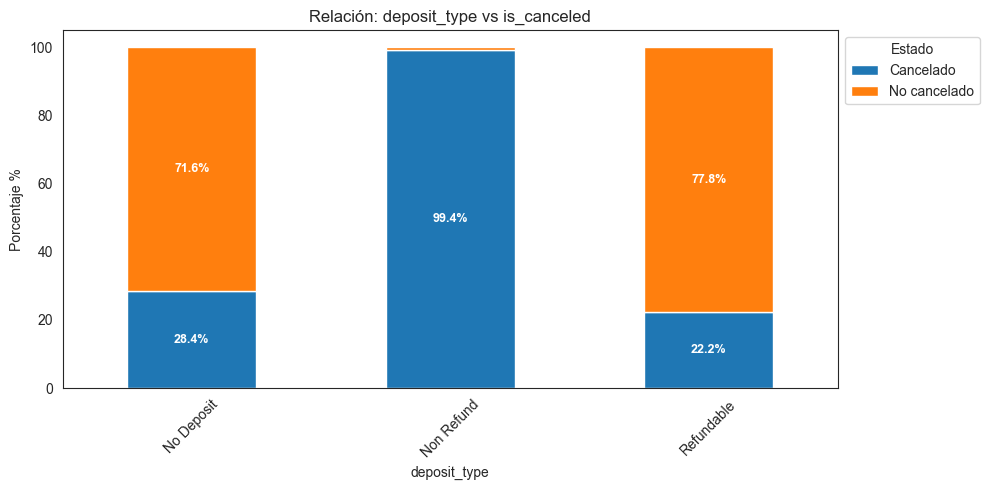

Saltando agent: Alta cardinalidad (334 categorías)


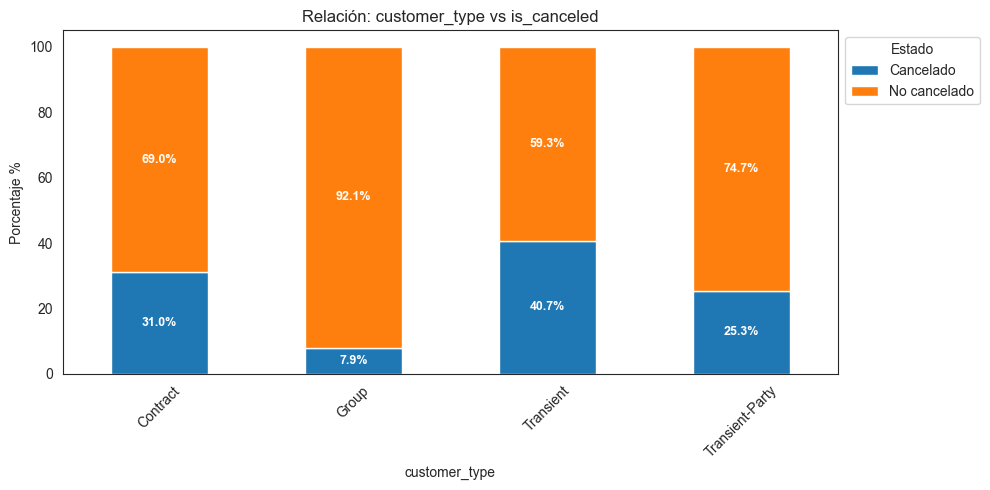

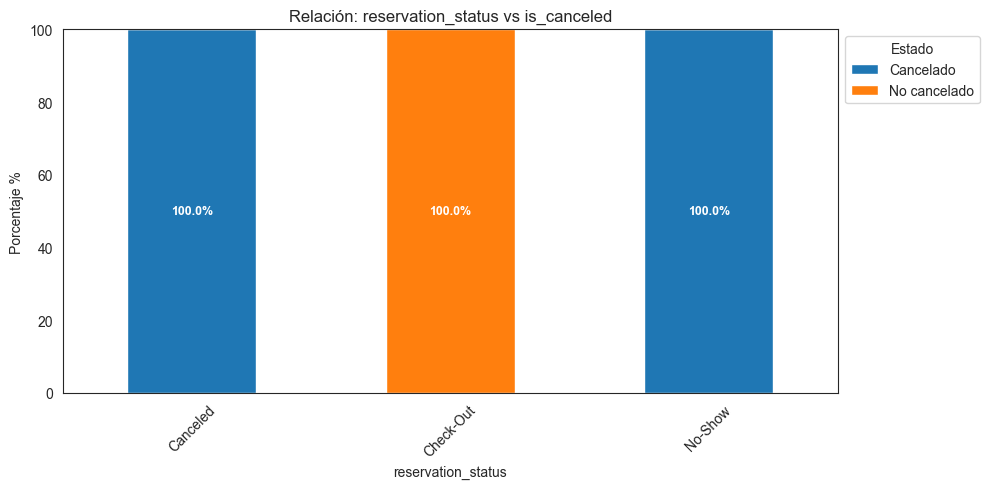

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. ANÁLISIS DE CORRELACIÓN CON VARIABLES NUMÉRICAS ---

# Creamos una copia para no alterar el dataframe original de entrenamiento
data_num = data_clean.copy()

# Mapeo explícito a entero para asegurar que sea detectada como columna numérica
# Usamos .astype(int) para evitar que pandas la interprete como 'object'
data_num['is_canceled_bool'] = data_num['is_canceled'].map({
    "No cancelado": 0, 
    "Cancelado": 1
}).astype(int)

# Seleccionamos solo las columnas numéricas (ahora incluirá 'is_canceled_bool')
numeric_cols = data_num.select_dtypes(include=[np.number]).columns
corr_matrix = data_num[numeric_cols].corr()

# Extraemos la correlación con el target, ordenamos y eliminamos la autocorrelación
corr_target = corr_matrix['is_canceled_bool'].sort_values(ascending=False).drop('is_canceled_bool')

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="RdBu_r")
plt.title("Correlación de Pearson: Variables Numéricas vs is_canceled")
plt.xlabel("Coeficiente de Correlación")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# --- 2. ANÁLISIS DE CORRELACIÓN CON VARIABLES CATEGÓRICAS ---

def plot_categorical_correlation(df, col, target='is_canceled'):
    """
    Genera un gráfico de barras apiladas al 100% para visualizar la 
    proporción de cancelaciones por categoría.
    """
    if df[col].nunique() > 15:
        print(f"Saltando {col}: Alta cardinalidad ({df[col].nunique()} categorías)")
        return

    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    
    ax = ct.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#1f77b4', '#ff7f0e'])
    plt.title(f"Relación: {col} vs {target}")
    plt.ylabel("Porcentaje %")
    plt.xlabel(col)
    plt.legend(title="Estado", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45)
    
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5: # Solo mostrar si el segmento es lo suficientemente grande
            x, y = p.get_xy() 
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

vars_categorical = data_clean.select_dtypes(include=['object', 'category']).columns.tolist()

for var in vars_categorical:
    if var != 'is_canceled':
        plot_categorical_correlation(data_clean, var)

## Data Leakage

In [65]:
# reservation_status:  esta variable indica si el cliente hizo el Check-out o canceló. Tiene una correlación de casi el 100% con is_canceled. 
# Decision: Eliminar obligatoriamente.
data_clean.drop(columns=['reservation_status'], inplace=True)

In [66]:
# reservation_status_date: Esta es la fecha en la que se actualizó el último estado. Si una reserva se canceló el 15 de julio, esta fecha será el 15 de julio. Un modelo no puede saber esta fecha al momento de recibir la reserva. 
# Decision: Eliminar obligatoriamente.
data_clean.drop(columns=['reservation_status_date'], inplace=True)

In [67]:
# Eliminar expected expected_revenue_loss: Esta columna parece ser un cálculo posterior basado en si la reserva se canceló o no. Es información del "futuro".
# Decision: Eliminar obligatoriamente.
# data_clean.drop(columns=['expected_revenue_loss'], inplace=True)    

In [68]:
#por obsrvacion dee correlacion, deposit_type esta altamente correlacionada, esta conentrado en cancelado el non refund. 
'''
La variable deposit_type tiene tres valores:

No Deposit → el cliente no garantizó nada
Non Refund → pagó un depósito no reembolsable
Refundable → pagó un depósito reembolsable

El problema: En este dataset, Non Refund está codificado después de que el cliente canceló. 
El hotel aplica el cargo "Non Refund" en el momento de la cancelación, no en el momento de la reserva. 
Entonces el modelo aprende: Non Refund = Cancelado con correlación cercana a 1.
'''


#Decision: Binarizar para no poderderla 
# data_clean['deposit_type_binary'] = data_clean['deposit_type'].apply(lambda x: 1 if x == 'Non Refund' else 0)
#Decision: Eliminar la variable original deposit_type para evitar que el modelo la use y se confunda con is_canceled.
# data_clean.drop(columns=['deposit_type'], inplace=True)

'\nLa variable deposit_type tiene tres valores:\n\nNo Deposit → el cliente no garantizó nada\nNon Refund → pagó un depósito no reembolsable\nRefundable → pagó un depósito reembolsable\n\nEl problema: En este dataset, Non Refund está codificado después de que el cliente canceló. \nEl hotel aplica el cargo "Non Refund" en el momento de la cancelación, no en el momento de la reserva. \nEntonces el modelo aprende: Non Refund = Cancelado con correlación cercana a 1.\n'

## Resignificacion / simplificacion

In [69]:
#assigned_room_type: Aunque parece útil, a menudo el tipo de habitación se asigna en el momento del check-in o muy cerca de la fecha de llegada. Si el hotel asigna una habitación diferente a la reservada (reserved_room_type) debido a una sobreventa o cancelación previa, estás dándole pistas al modelo sobre el estado operativo del hotel en el futuro.
# Nota: Es mejor usarla solo para crear una variable "Delta" (si son diferentes o no) y luego droppear la columna original.

#crear esta variable tal quie se produzca una var "Delta" (si son diferentes o no) y luego droppear la columna original.
# Convertimos a string para comparar sin conflictos de categorías
data_clean['room_type_mismatch'] = (
    data_clean['assigned_room_type'].astype(str) != 
    data_clean['reserved_room_type'].astype(str)
).astype(int)

# Ahora eliminamos la columna deseada
data_clean.drop(columns=['assigned_room_type'], inplace=True)


# Tabla final de datos que entran a featEng.


### Agrupación lógica de variables

| # | Dimensión | El... | Variables | Descripción |
|---|---|---|---|---|
| 1 | **Demanda y Segmentación** | *¿Quién?* | `adults`, `children`, `babies`, `country`, `customer_type`, `market_segment`, `distribution_channel` | Perfil del cliente y canal de llegada. Clave para entender elasticidad y comportamiento de cancelación por segmento. |
| 2 | **Temporalidad y Estacionalidad** | *¿Cuándo?* | `arrival_date_year`, `arrival_date_month`, `arrival_date_week_number`, `arrival_date_day_of_month`, `stays_in_weekend_nights`, `stays_in_week_nights`, `lead_time` | Ubican la reserva en el tiempo. Suelen tener el mayor peso predictivo por dinámicas de temporada alta/baja. |
| 3 | **Fidelidad y Riesgo** | *¿Historial?* | `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled` | Lo que sabemos del cliente por visitas pasadas. Mide la "confianza" y el riesgo de incumplimiento. |
| 4 | **Producto y Operación** | *¿Qué?* | `hotel`, `reserved_room_type`, `assigned_room_type`, `meal`, `required_car_parking_spaces`, `total_of_special_requests` | Infraestructura y servicios solicitados. Discrepancias entre habitación reservada y asignada pueden disparar cancelaciones. |
| 5 | **Financiera y Contractual** | *¿Cómo?* | `adr`, `deposit_type`, `agent`, `company` | Valor económico y condiciones legales de la reserva. |
| 6 | **Gestión y Estado** | *¿Resultado?* | `booking_changes`, `days_in_waiting_list`, `is_canceled` *(target)*, `reservation_status`, `reservation_status_date` *(auditoría)* | Variables que cambian post-reserva. `reservation_status` y `reservation_status_date` se eliminan por leakage antes del modelado. |

In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap
import os

# 1. Configurar ruta de guardado y asegurar que el directorio existe
output_dir = "Figures/EDA"
output_filename = "013_Tabla final tipo paper.png"
os.makedirs(output_dir, exist_ok=True)
path_final = os.path.join(output_dir, output_filename)

# 2. Definición de Datos: Target PRIMERO
target_row = ["Variable a predecir", "is_canceled"]

data_raw = [
    ["Demografía", "adults, children, babies, country, customer_type"],
    ["Fidelidad", "is_repeated_guest, previous_cancellations, previous_bookings_not_canceled"],
    ["Reserva", "hotel, lead_time, market_segment, distribution_channel, agent"],
    ["Temporalidad", "arrival_date_year, arrival_date_month, arrival_date_week_number, arrival_date_day_of_month"],
    ["Estancia", "stays_in_weekend_nights, stays_in_week_nights, room_type_mismatch"],
    ["Finanzas", "meal, adr, deposit_type"],
    ["Gestión de Reserva", "booking_changes, days_in_waiting_list, total_of_special_requests"],
]

# 3. Configuración de la figura y el canvas
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 10)
# Ajustamos el ylim para dar espacio al header y al target al principio
ax.set_ylim(-1, len(data_raw) + 4) 
ax.axis('off')

# Parámetros de diseño
y_start = len(data_raw) + 2.5
col1_x = 0.5
col2_x = 3.5
line_width_main = 2.0
line_width_sub = 1.0

# 4. DIBUJAR ENCABEZADO (Encadrado entre barras dobles)
# Línea superior gruesa
ax.axhline(y=y_start + 0.8, xmin=0.05, xmax=0.95, color='black', linewidth=line_width_main)

# Texto de encabezado centrado verticalmente
ax.text(col1_x, y_start + 0.25, "Categoría", weight='bold', fontsize=13, family='serif')
ax.text(col2_x, y_start + 0.25, "Variables nativas incluidas", weight='bold', fontsize=13, family='serif')

# Línea inferior fina del header
ax.axhline(y=y_start, xmin=0.05, xmax=0.95, color='black', linewidth=line_width_sub)

# 5. DIBUJAR FILA TARGET (Destacada: Amarilla + Bold)
current_y = y_start - 0.7

# Crear el rectángulo amarillo de fondo (Highlight)
highlight_height = 0.7
rect = patches.Rectangle((0.4, current_y - 0.55), 9.2, highlight_height, 
                         linewidth=0, edgecolor='none', facecolor='yellow', alpha=0.3, zorder=0)
ax.add_patch(rect)

# Texto del target en negrita
ax.text(col1_x, current_y, target_row[0], weight='bold', fontsize=12, family='serif', va='top', zorder=1)
ax.text(col2_x, current_y, target_row[1], weight='bold', fontsize=12, family='serif', va='top', zorder=1)

# Espacio extra después del target
current_y -= 1.0

# 6. DIBUJAR RESTO DE FILAS NORMALES
for cat, vars_text in data_raw:
    # Categoría en Negrita
    ax.text(col1_x, current_y, cat, weight='bold', fontsize=11, family='serif', va='top')
    
    # Variables con salto de línea dinámico (Wrapping)
    wrapped_text = textwrap.fill(vars_text, width=65)
    ax.text(col2_x, current_y, wrapped_text, fontsize=11, family='serif', va='top')
    
    # Calcular espacio para la siguiente fila basado en el wrap
    num_lines = wrapped_text.count('\n') + 1
    current_y -= (0.45 + (num_lines * 0.28))

# 7. LÍNEA FINAL (Cierre de tabla)
# Ajuste fino para la línea final basada en la última posición
ax.axhline(y=current_y + 0.1, xmin=0.05, xmax=0.95, color='black', linewidth=line_width_main)

# 8. GUARDAR A ALTA CALIDAD (300 DPI)
plt.savefig(path_final, 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white',
            transparent=False)

plt.close(fig)
print(f"¡Éxito! La tabla ha sido guardada en: {path_final}")

¡Éxito! La tabla ha sido guardada en: Figures/EDA\013_Tabla final tipo paper.png


In [ ]:
!pip freeze > requirements_01_eda.txt